# Benchmark 1D 

In [11]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from time import perf_counter
import tensorflow as tf

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az
import keras


from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)

True

In [12]:
seed = 11
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

# Creation of the model

In [13]:
#Benchmark1
lowfid = lambda x: np.sin(8*np.pi*x/5)
highfid = lambda x: (x/5-np.sqrt(2))*lowfid(x)**2
Nhf = 15
Nlf = 64
N = Nhf + Nlf
xhf = np.linspace(0,5,Nhf)
xlf = np.linspace(0,5,Nlf)
x_test = np.linspace(0,5,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)
NepoLF = 3000
NepoHF = 3000

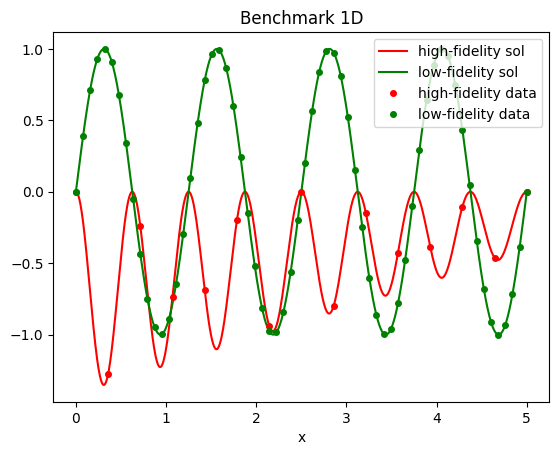

In [14]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model

The function training took 6.896477222442627 seconds.


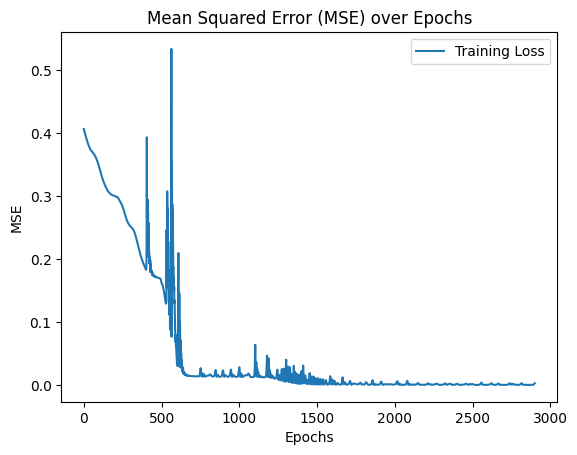

Test MSE: 0.8942313806587263
R^2: -5.603117216342863


In [15]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=NetworkFactory.build_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)
(mse_LF,R_LF)=modelLF.performance(x_test,highfid(x_test))

## High fidelity model

The function training took 6.9885804653167725 seconds.


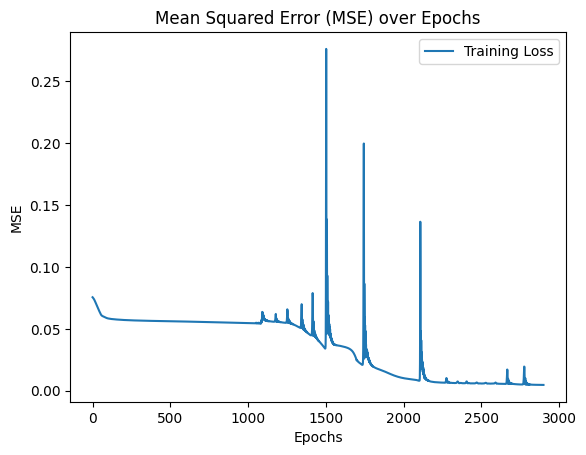

Test MSE: 0.12827111731746998
R^2: 0.05282990349254424


In [16]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=NetworkFactory.build_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)
(mse_HF,R_HF)=modelHF.performance(x_test,highfid(x_test))

## 2 Step model

The function training took 6.6493682861328125 seconds.


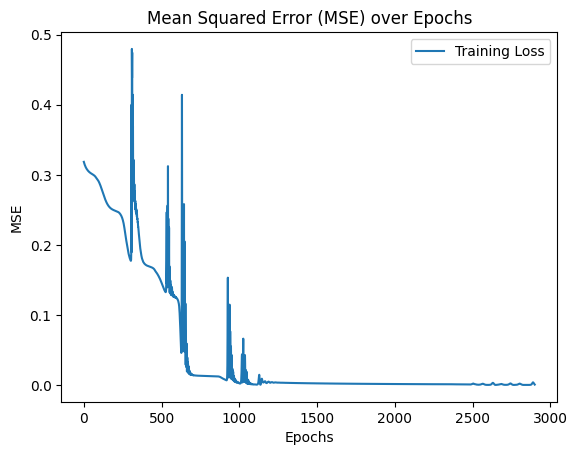

The function training took 6.021368026733398 seconds.


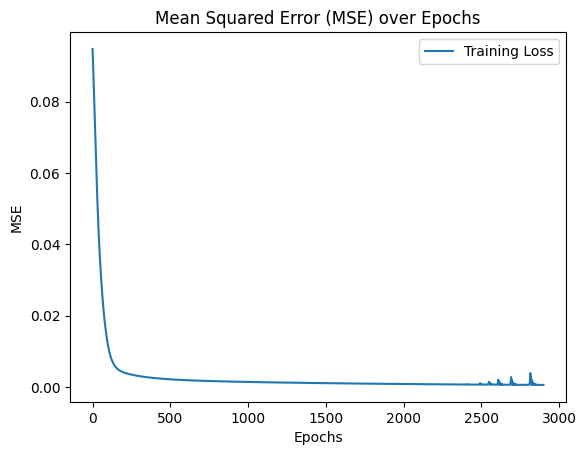

Test MSE: 0.0010247534759635212
R^2: 0.9924330911819965


In [17]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','HF']

params=[bestLF_params,best_params]
final_model=NetworkFactory.build_network("2step",names,params=params,data_train=[xlf,xhf],output_train=[Ylf,Yhf],N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

input_HF = np.concatenate(
                    (x_test.reshape(-1,1),  final_model.model_list[0].prediction(x_test).reshape(-1,1)),axis=1
                ) 
(mse_MF,R_MF)=final_model.model_list[1].performance(input_HF,highfid(x_test))

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

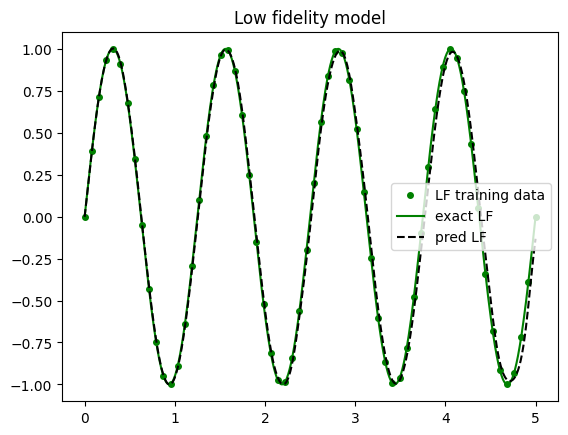

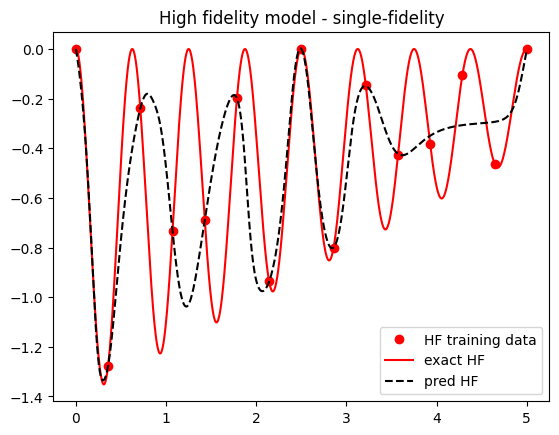

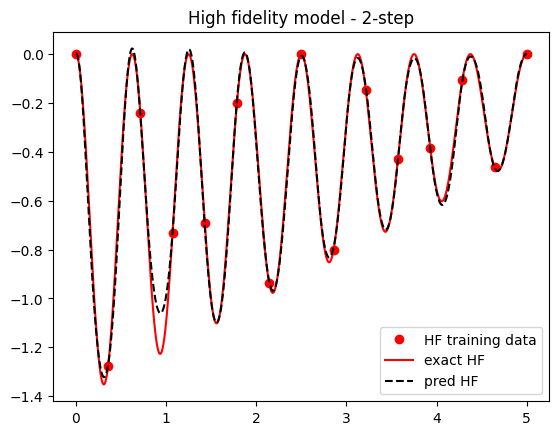

In [18]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC using tinyDA

In [19]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([1.,2.,3.,4.])
mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.1  # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.55
rwmh_cov = np.eye(len(real_x)) # !
rmwh_scaling = 0.01
rwmh_adaptive = False
iterations =8000
burnin = 4000
n_chains=4

real values are [1. 2. 3. 4.]
Sampling chain 1/4


Running chain, α = 0.27: 100%|██████████| 8000/8000 [11:28<00:00, 11.62it/s]


Sampling chain 2/4


Running chain, α = 0.38: 100%|██████████| 8000/8000 [11:07<00:00, 11.98it/s]


Sampling chain 3/4


Running chain, α = 0.36: 100%|██████████| 8000/8000 [12:30<00:00, 10.66it/s]


Sampling chain 4/4


Running chain, α = 0.37: 100%|██████████| 8000/8000 [13:40<00:00,  9.75it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.448 2.507 2.531 2.453]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.448  0.711   0.996    3.657      0.022    0.016    1001.0    1514.0   
x1  2.507  0.699   1.127    3.749      0.023    0.016     935.0    1491.0   
x2  2.531  0.697   1.145    3.734      0.025    0.017     804.0    1392.0   
x3  2.453  0.685   1.283    3.776      0.022    0.015     994.0    1653.0   

    r_hat  
x0   1.00  
x1   1.00  
x2   1.00  
x3   1.01  
Autocorrelation...
the difference between estimated values [1.448 0.507 0.469 1.547]
 the difference between outputs of two models are [0.9164259  0.35705829 0.26119873 0.50176702]


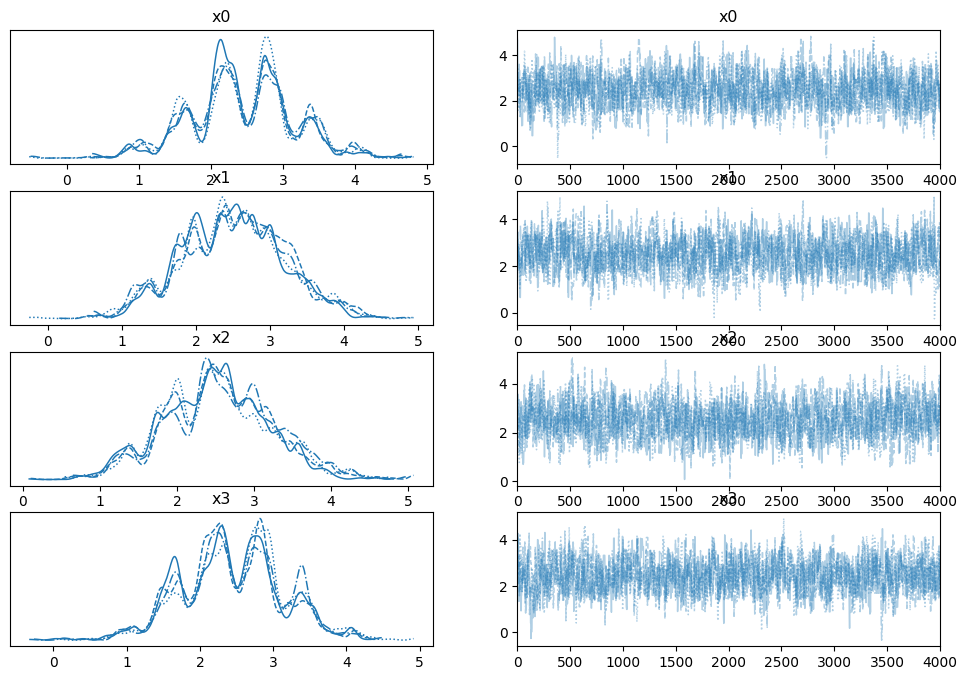

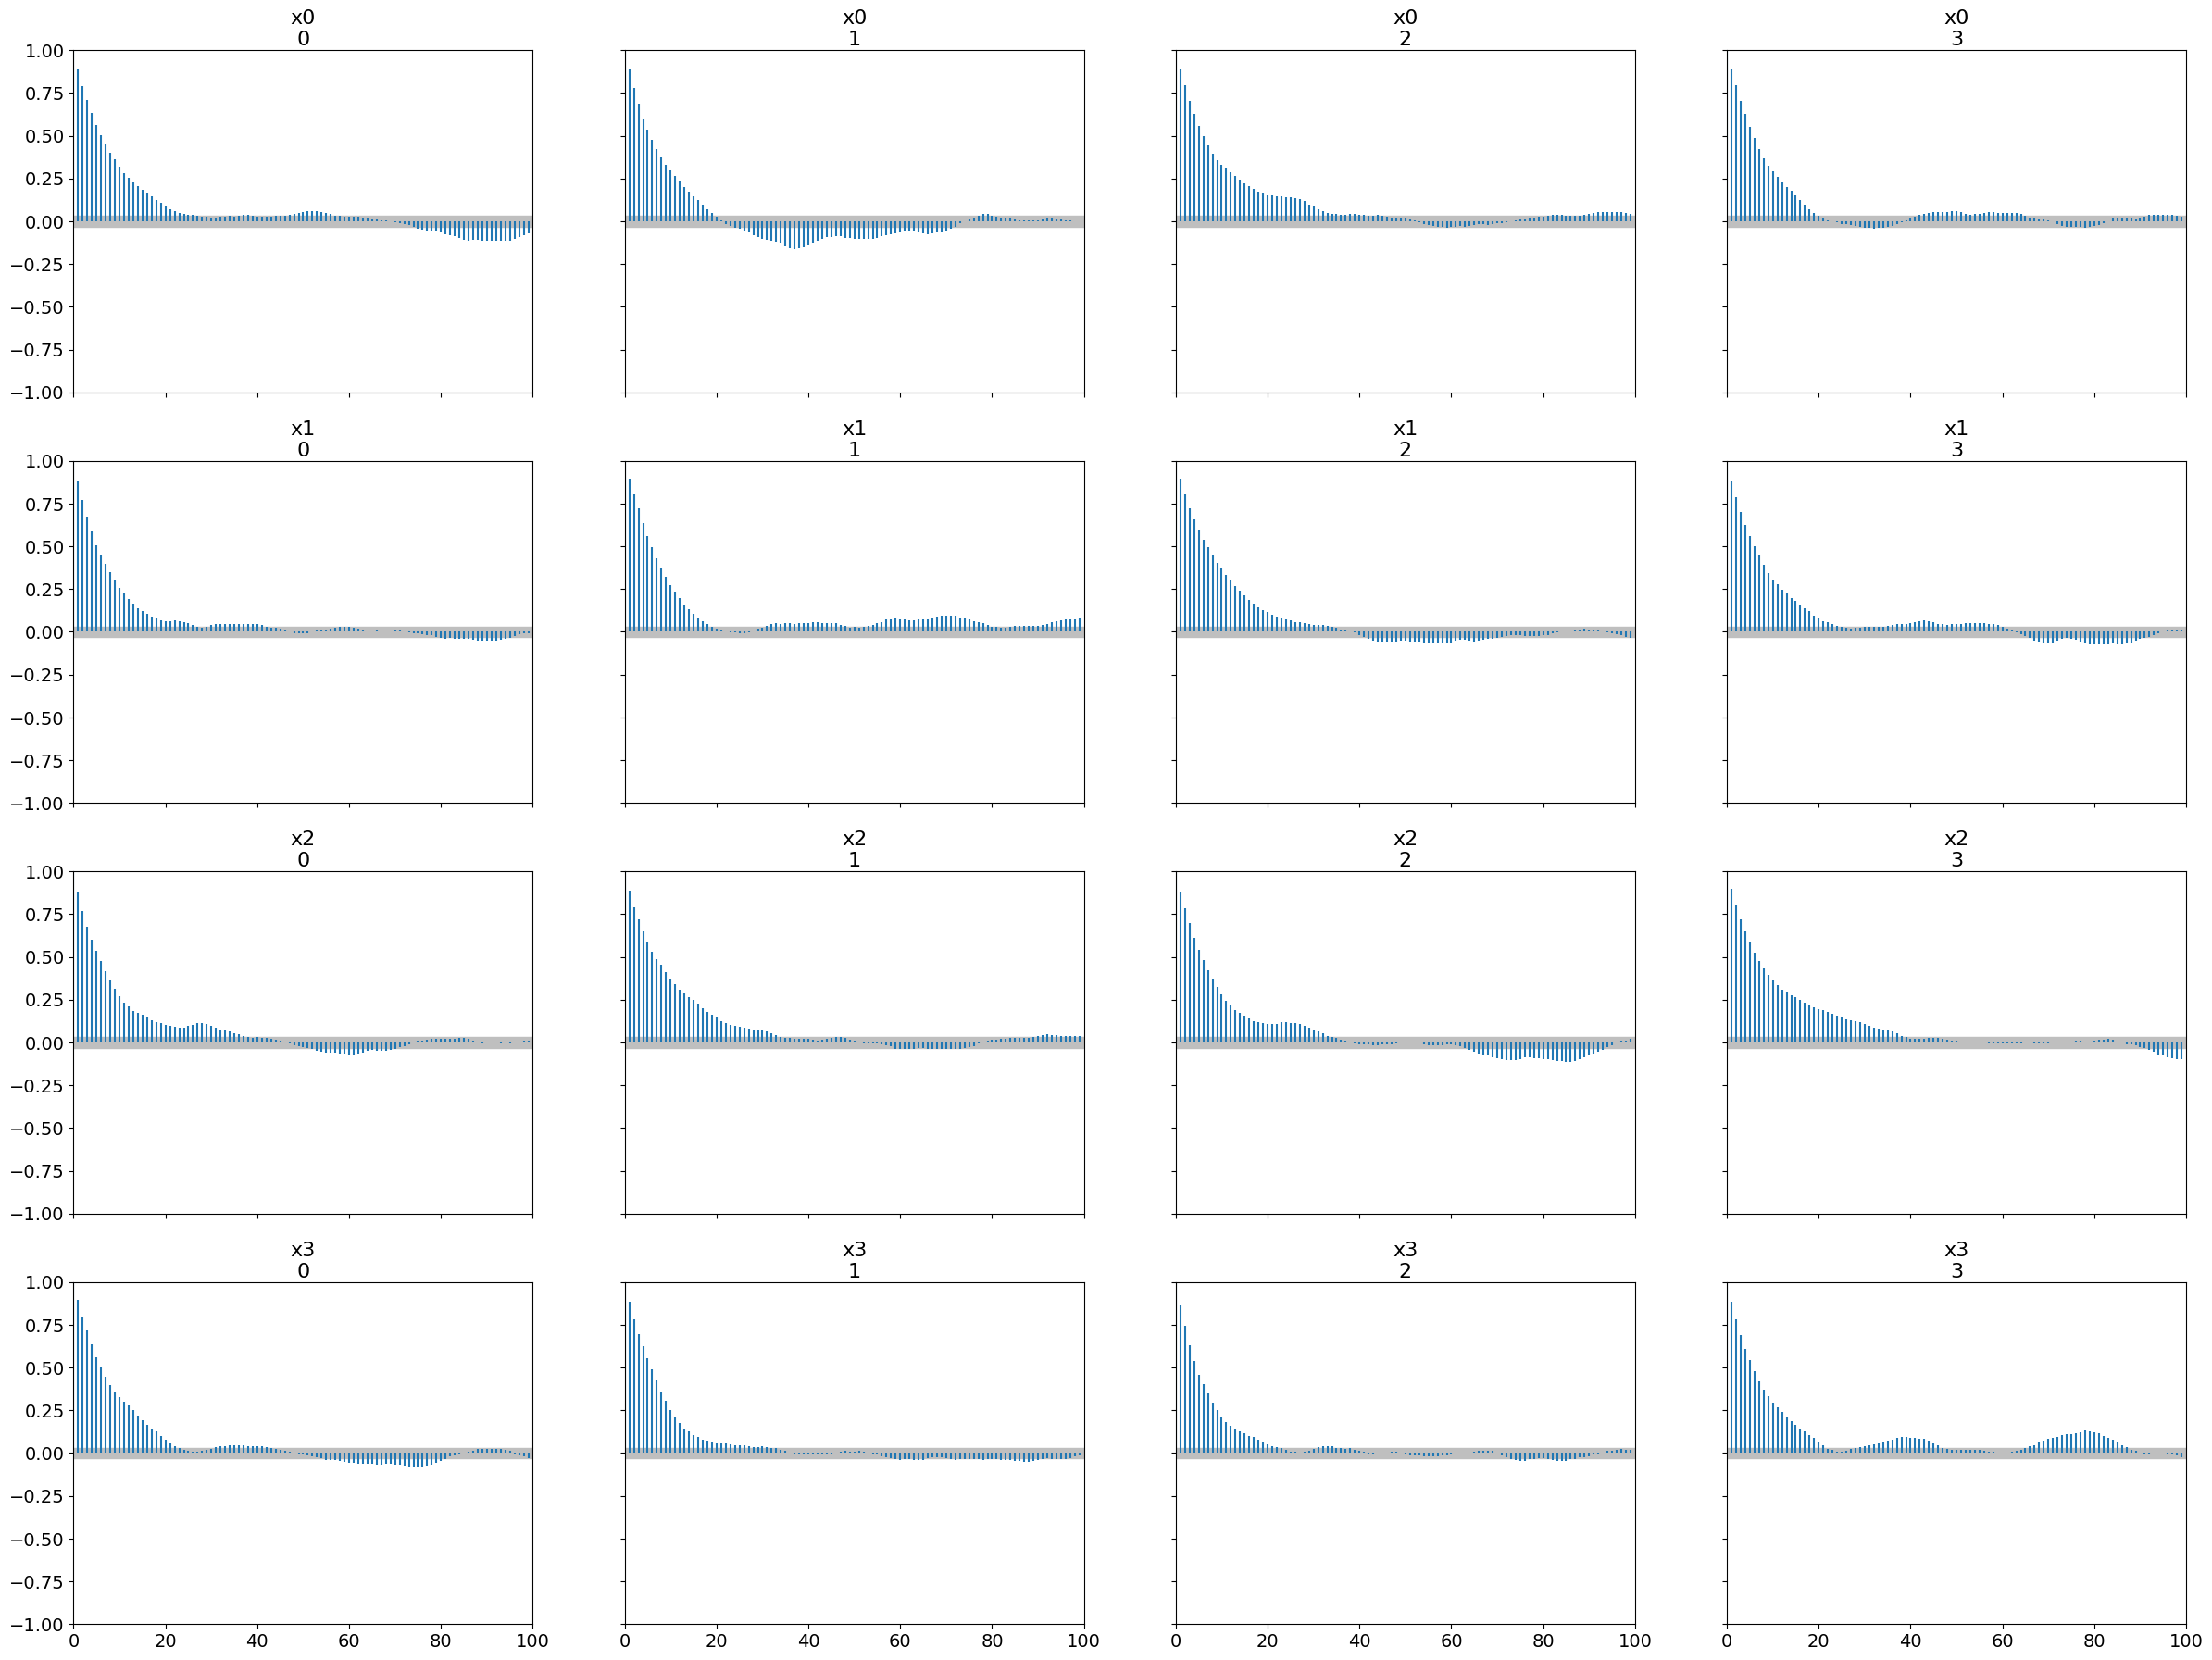

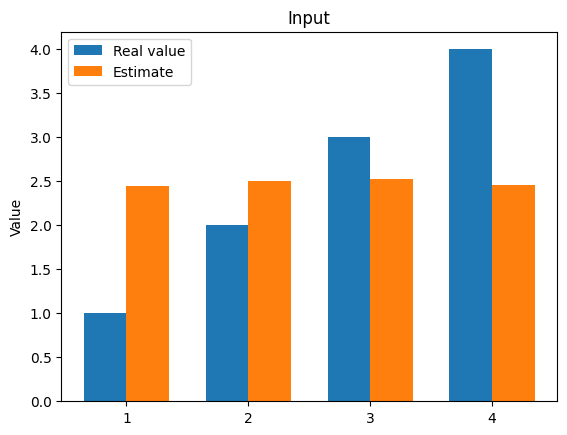

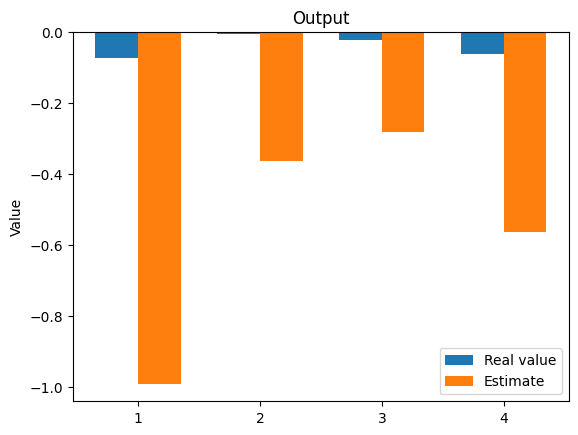

The function inverse took 2959.31831240654 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/4


Running chain, α = 0.00: 100%|██████████| 8000/8000 [07:42<00:00, 17.30it/s]


Sampling chain 2/4


Running chain, α = 0.09: 100%|██████████| 8000/8000 [06:39<00:00, 20.01it/s]


Sampling chain 3/4


Running chain, α = 0.06: 100%|██████████| 8000/8000 [06:49<00:00, 19.55it/s]


Sampling chain 4/4


Running chain, α = 0.14: 100%|██████████| 8000/8000 [06:35<00:00, 20.25it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.412 2.575 2.503 2.545]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.412  0.652   1.091    3.598      0.065    0.055     118.0     224.0   
x1  2.575  0.698   1.237    3.728      0.039    0.028     336.0     550.0   
x2  2.503  0.701   1.202    3.752      0.040    0.028     316.0     654.0   
x3  2.545  0.734   1.013    3.711      0.046    0.033     281.0     554.0   

    r_hat  
x0   1.05  
x1   1.01  
x2   1.01  
x3   1.01  
Autocorrelation...
the difference between estimated values [1.412 0.575 0.497 1.455]
 the difference between outputs of two models are [0.4895881  0.86941683 0.6732918  0.7392938 ]


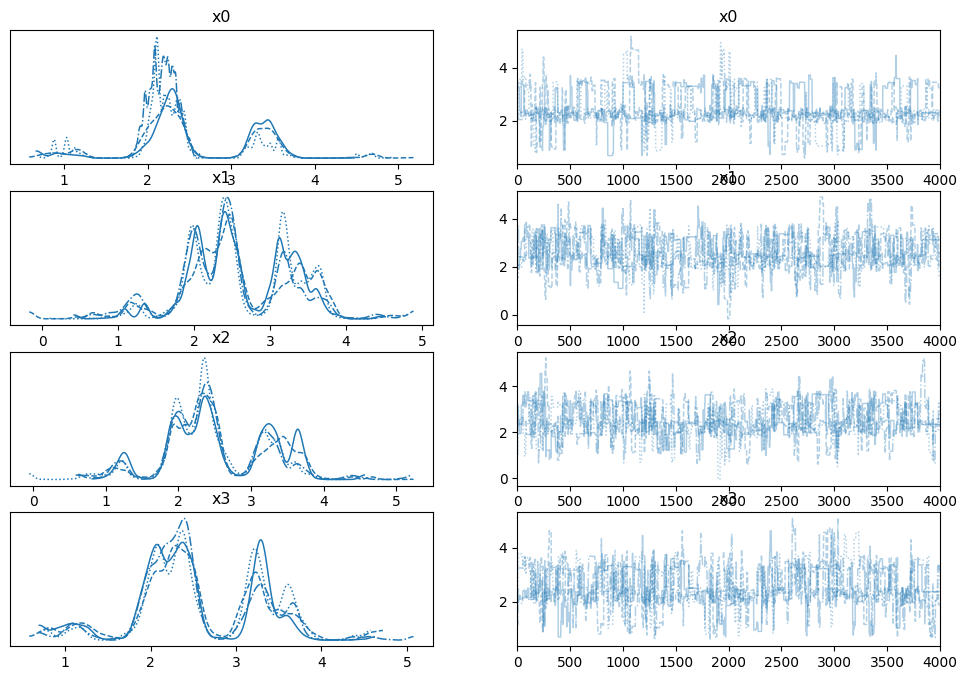

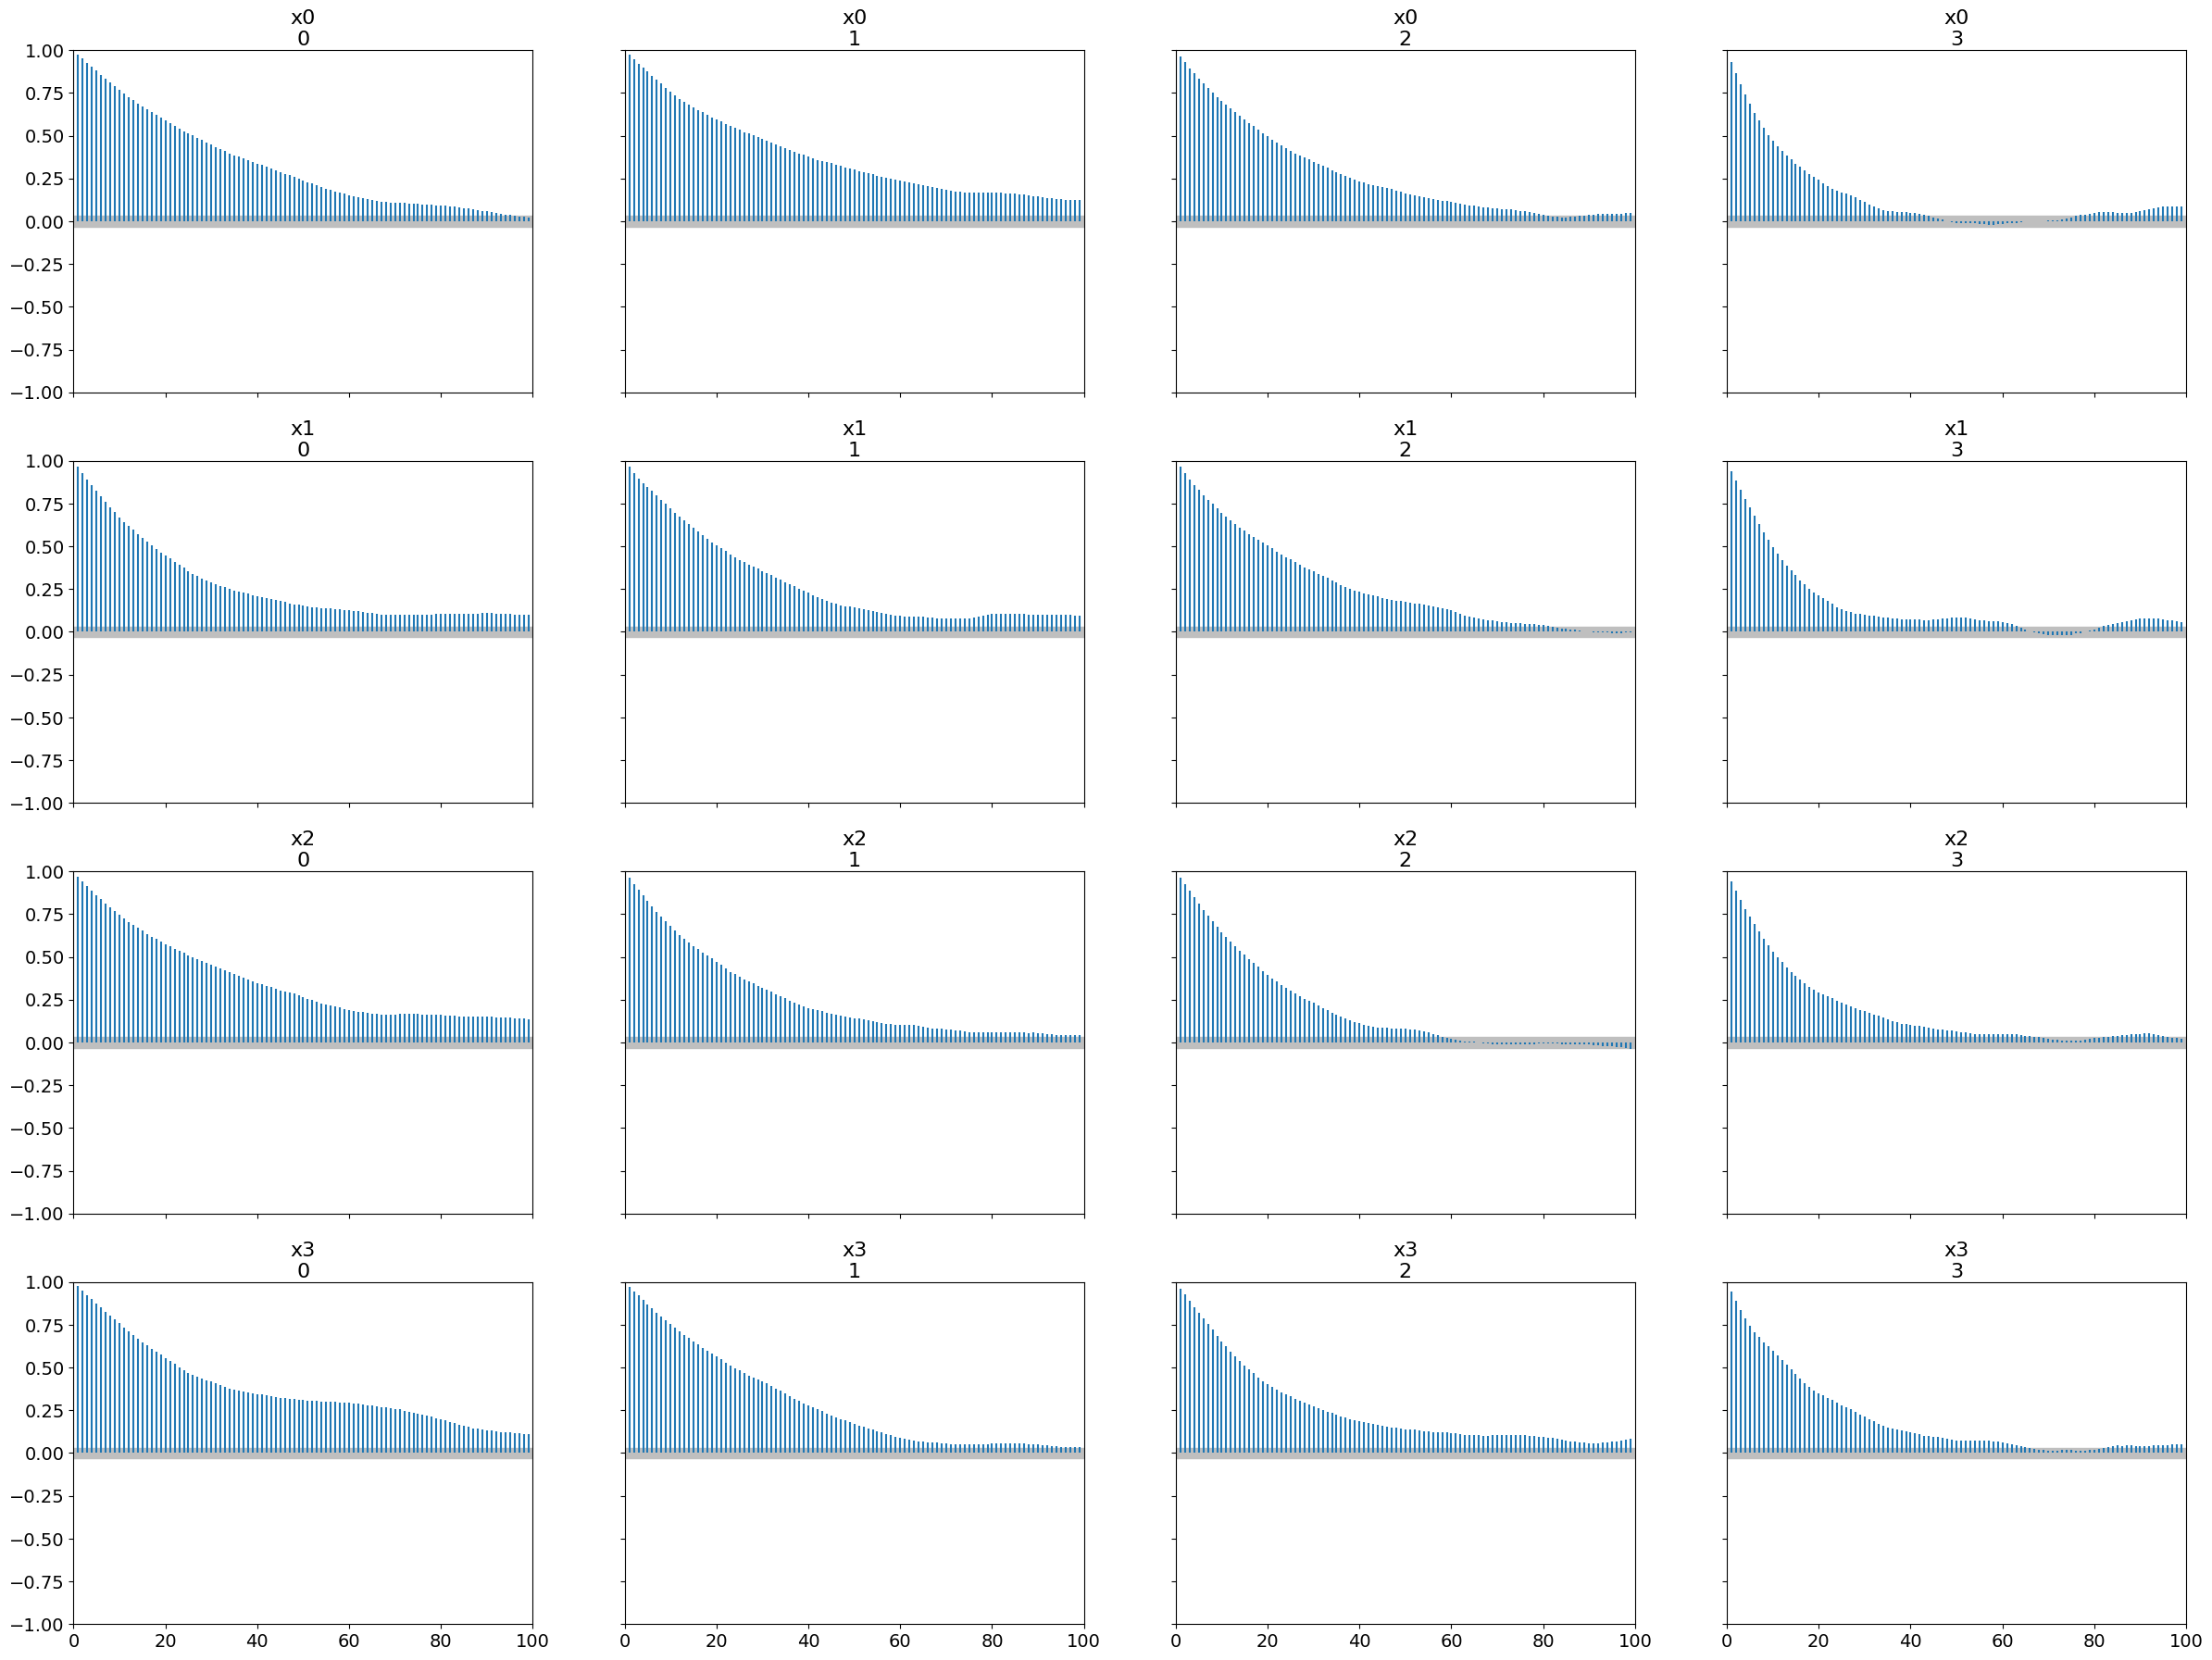

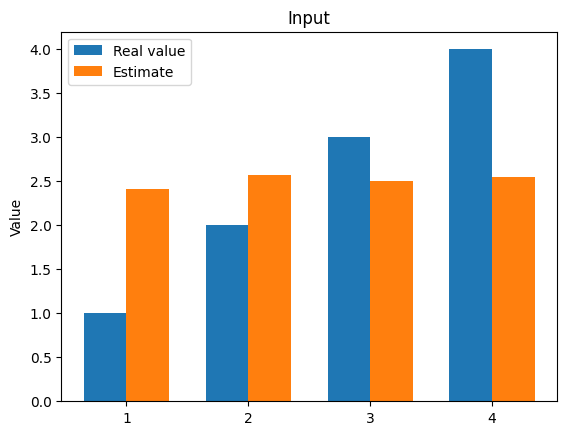

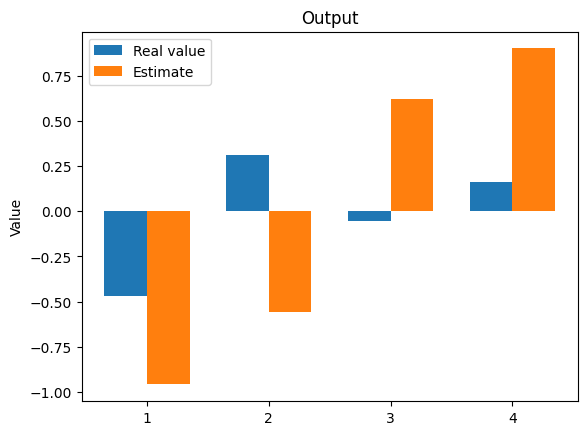

The function inverse took 1677.6680526733398 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/4


Running chain, α = 0.35: 100%|██████████| 8000/8000 [06:38<00:00, 20.06it/s]


Sampling chain 2/4


Running chain, α = 0.34: 100%|██████████| 8000/8000 [06:30<00:00, 20.51it/s]


Sampling chain 3/4


Running chain, α = 0.37: 100%|██████████| 8000/8000 [06:07<00:00, 21.80it/s]


Sampling chain 4/4


Running chain, α = 0.28: 100%|██████████| 8000/8000 [06:01<00:00, 22.12it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.372 2.541 2.54  2.491]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.372  0.663   1.088    3.570      0.024    0.017     787.0    1380.0   
x1  2.541  0.740   1.320    4.032      0.025    0.018     881.0    1579.0   
x2  2.540  0.711   1.327    3.933      0.022    0.016    1016.0    1524.0   
x3  2.491  0.719   1.148    3.813      0.025    0.017     852.0    1548.0   

    r_hat  
x0   1.00  
x1   1.00  
x2   1.01  
x3   1.01  
Autocorrelation...
the difference between estimated values [1.372 0.541 0.46  1.509]
 the difference between outputs of two models are [0.1886074  0.8802162  0.47093213 0.33728755]


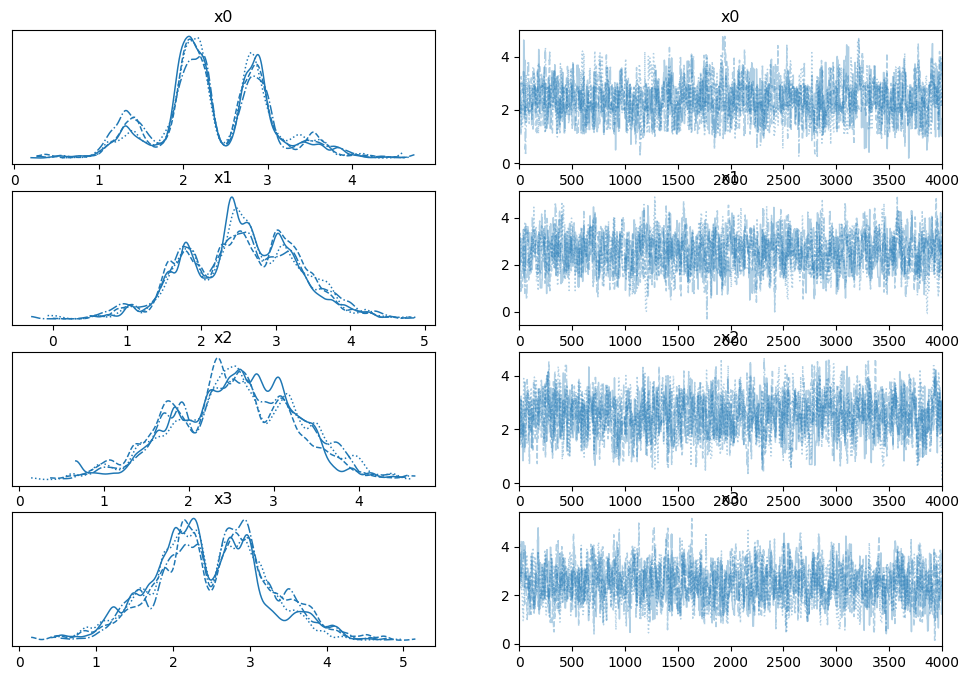

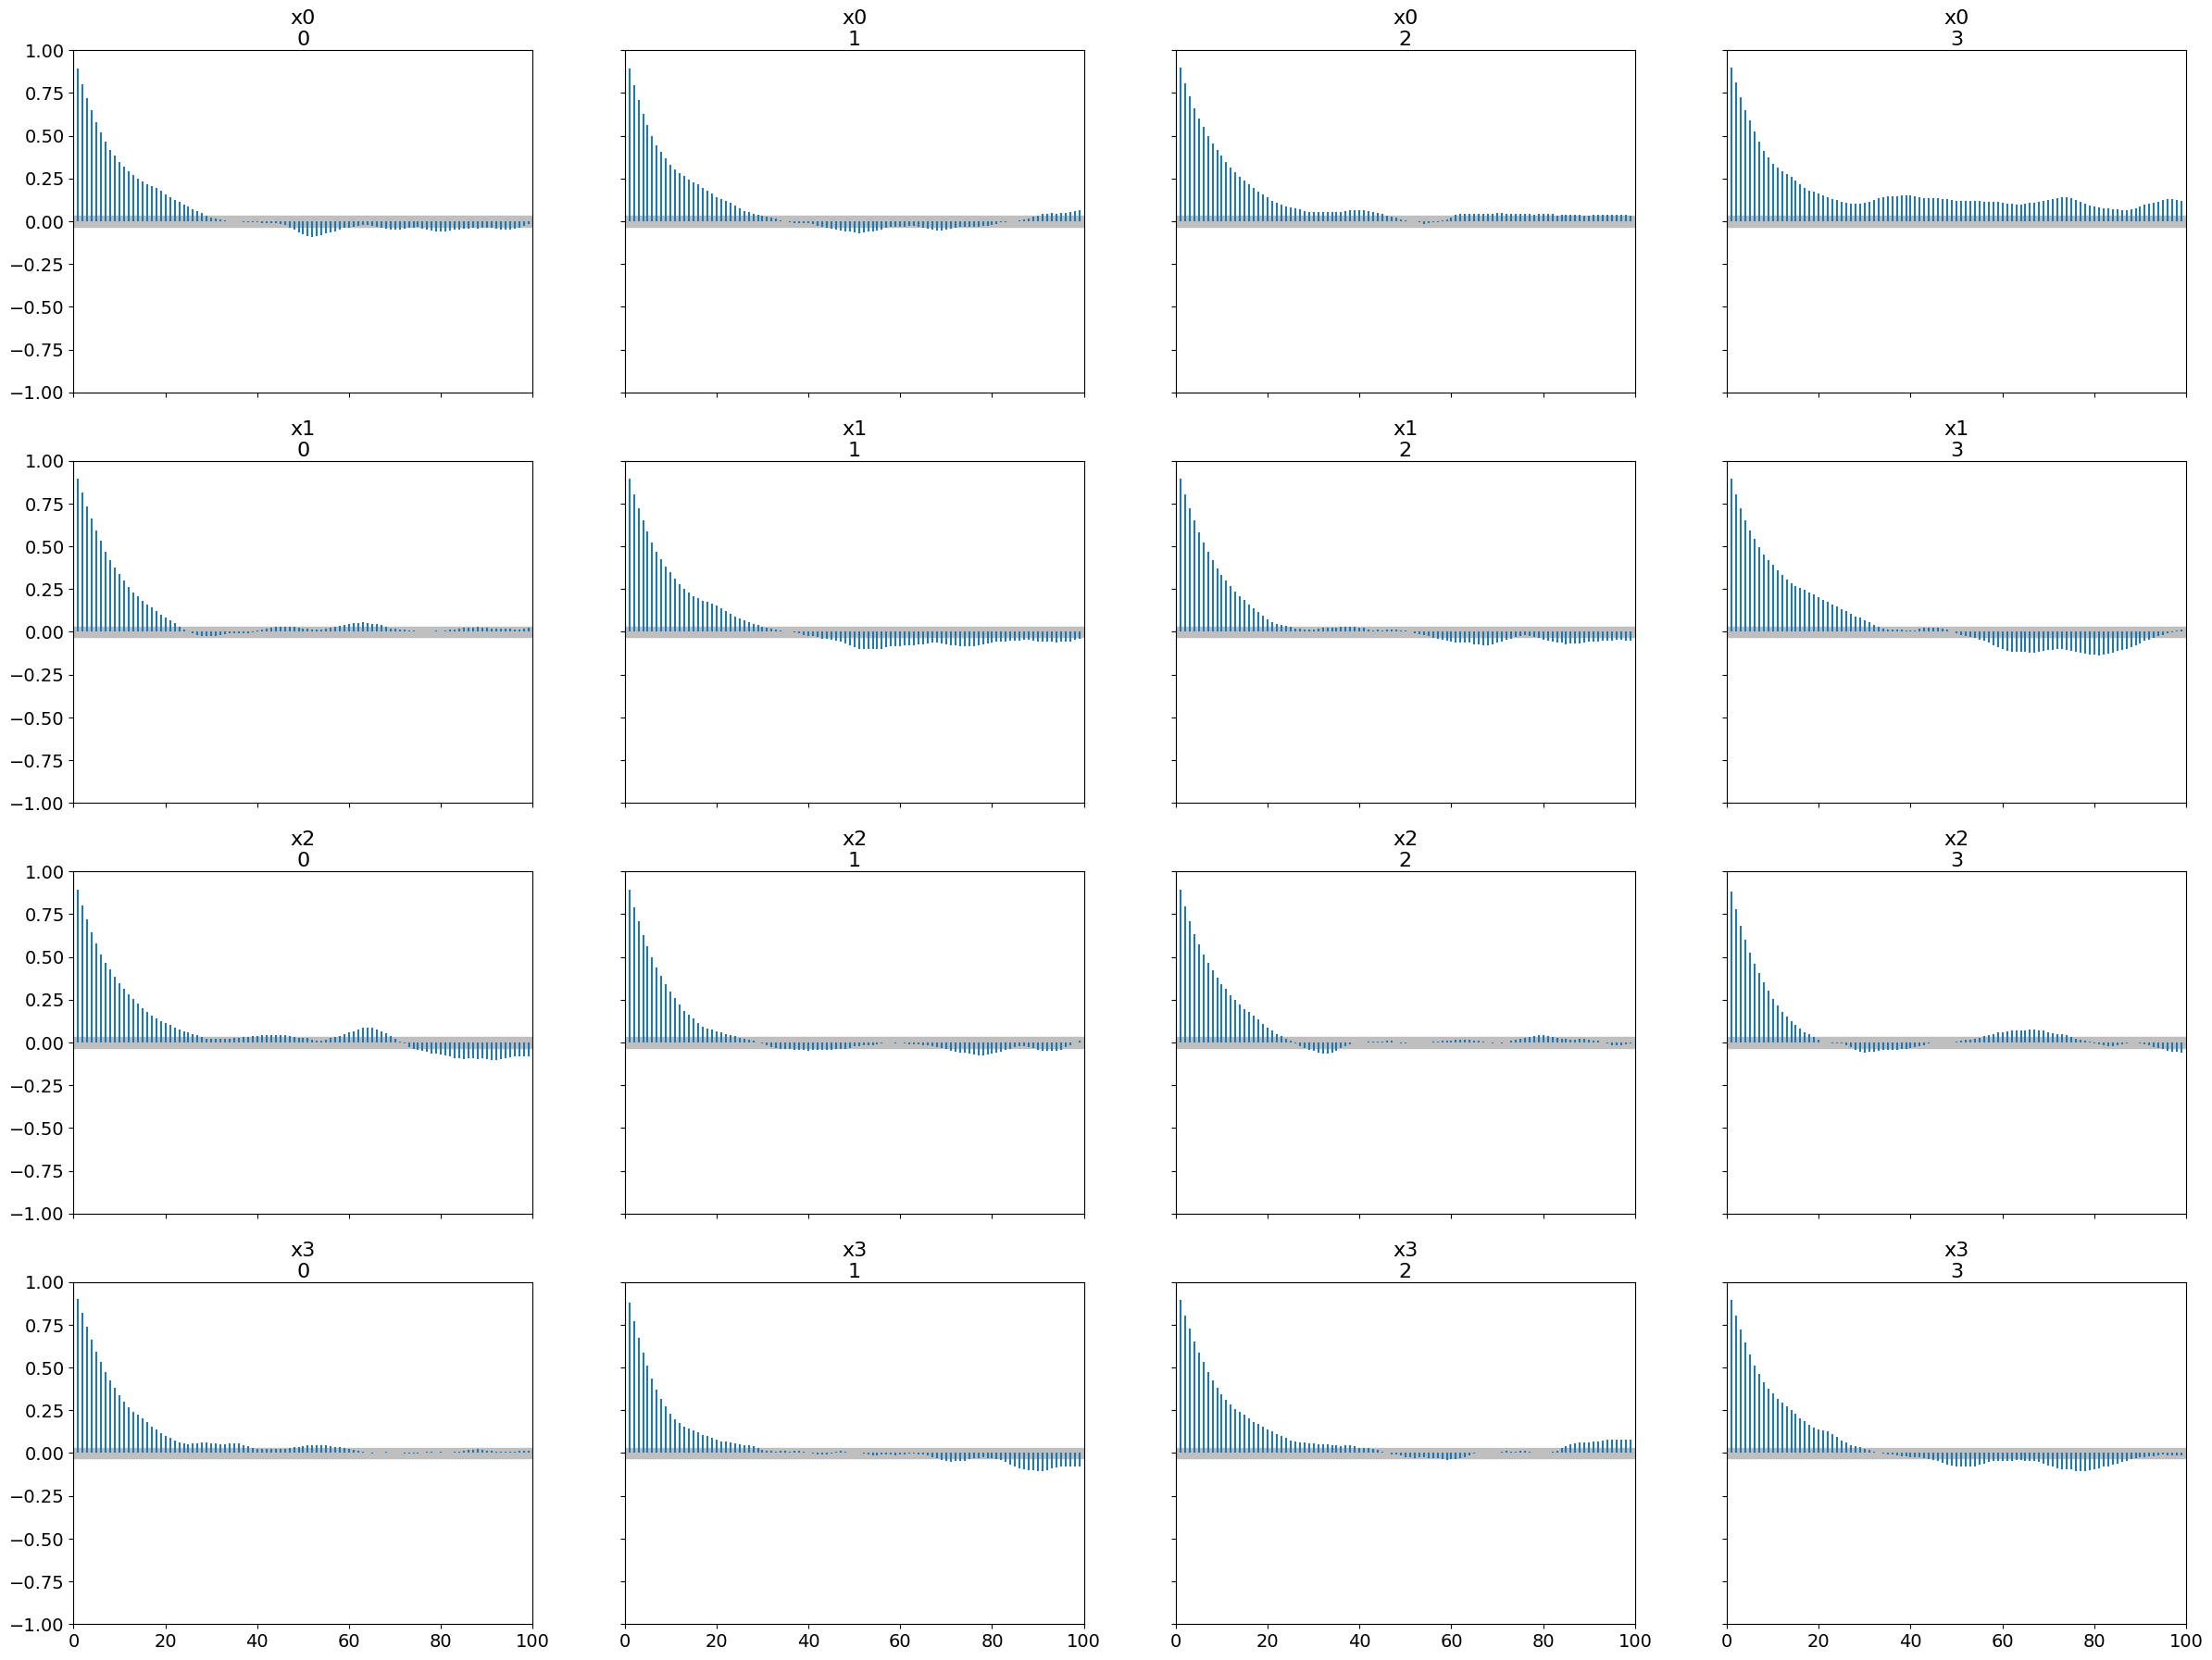

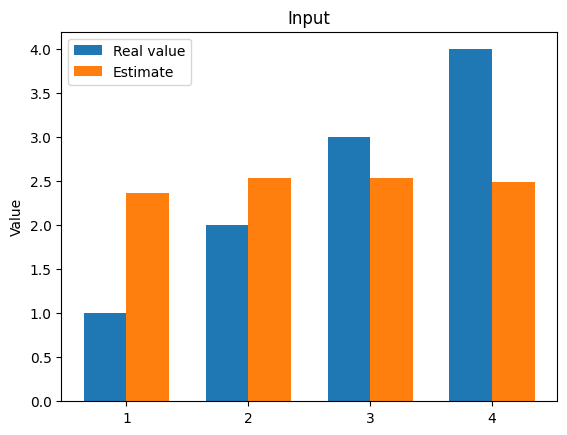

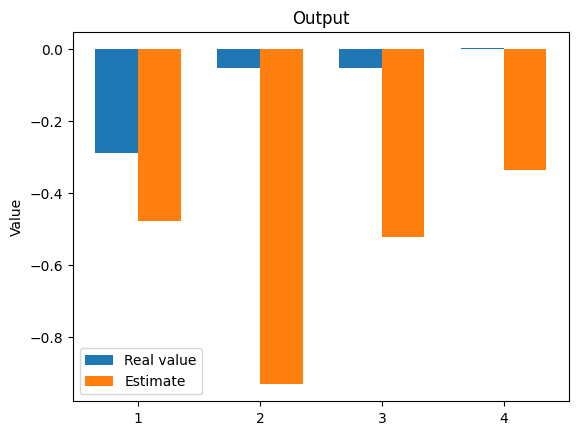

The function inverse took 1531.713749885559 seconds.


In [20]:
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=0.1, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive, algo="AM")
estimate_LF=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=0.1, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive, algo="AM")
estimate_HF=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=0.1, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,algo="AM")

### ripeto ma con noise inferiore

In [22]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([1.,2.,3.,4.])
mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.1  # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.55
rwmh_cov = np.eye(len(real_x)) # !
rmwh_scaling = 0.01
rwmh_adaptive = False
iterations =8000
burnin = 4000
n_chains=2

real values are [1. 2. 3. 4.]
Sampling chain 1/2


Running chain, α = 0.29: 100%|██████████| 8000/8000 [11:40<00:00, 11.42it/s]


Sampling chain 2/2


Running chain, α = 0.29: 100%|██████████| 8000/8000 [12:30<00:00, 10.67it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.422 2.534 2.601 2.503]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.422  0.672   1.109    3.595      0.030    0.022     488.0     644.0   
x1  2.534  0.701   1.267    3.918      0.036    0.025     391.0     581.0   
x2  2.601  0.714   1.165    3.850      0.041    0.029     305.0     680.0   
x3  2.503  0.708   1.102    3.802      0.036    0.026     381.0     729.0   

    r_hat  
x0   1.00  
x1   1.01  
x2   1.00  
x3   1.00  
Autocorrelation...
the difference between estimated values [1.422 0.534 0.399 1.497]
 the difference between outputs of two models are [0.83827722 0.33861846 0.09302431 0.55744264]


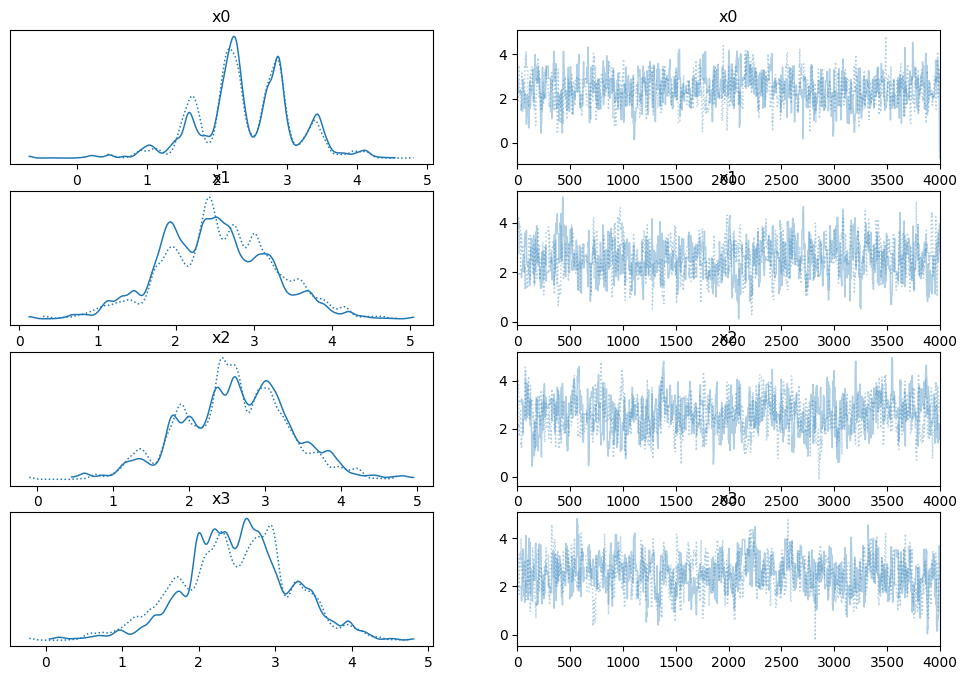

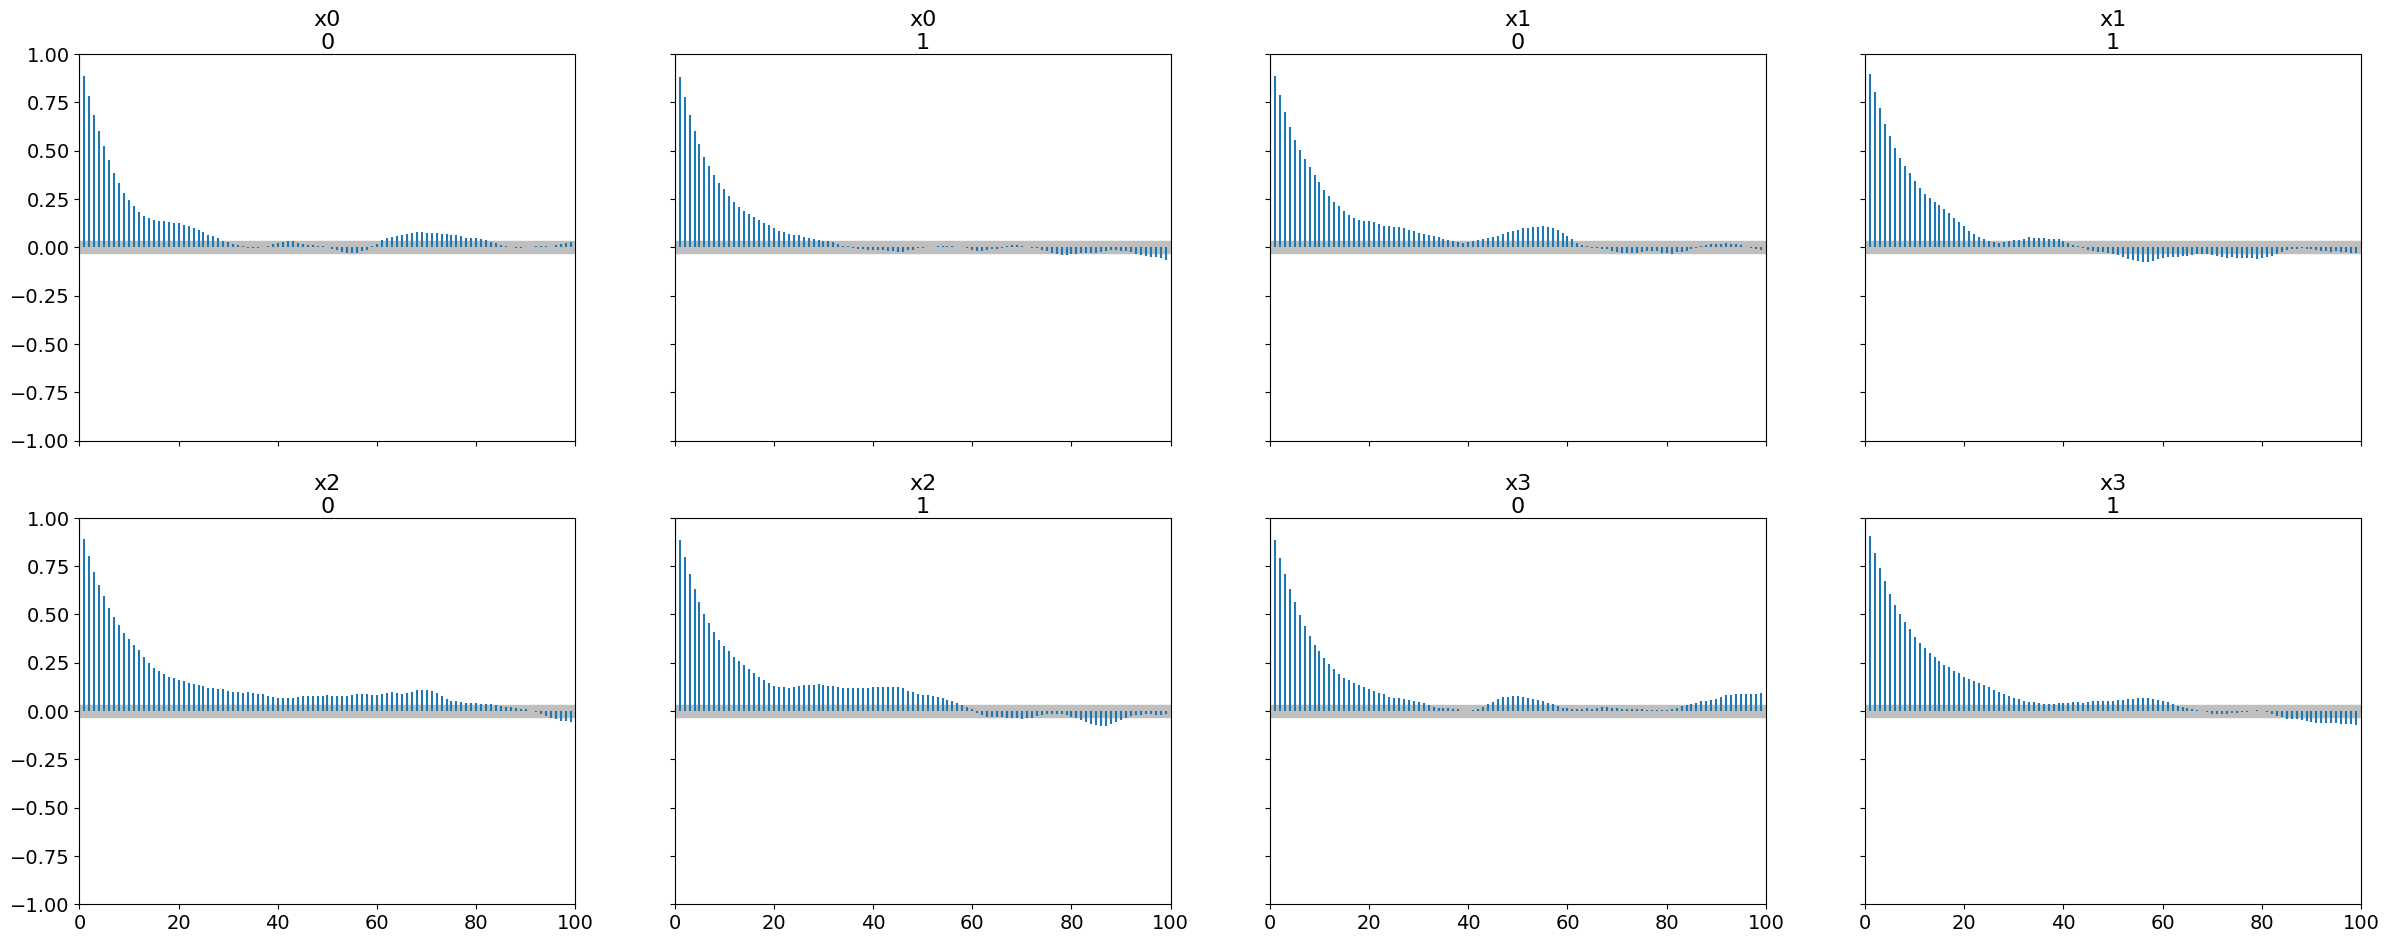

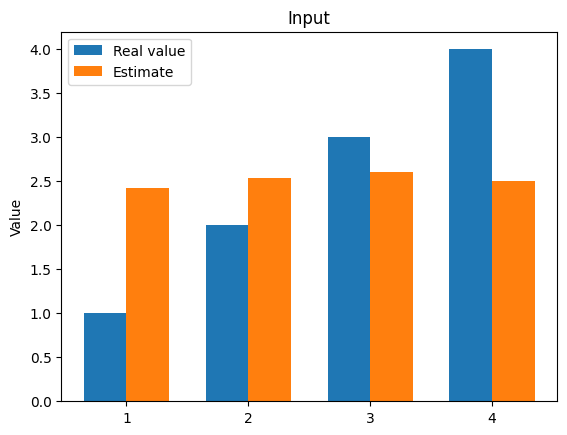

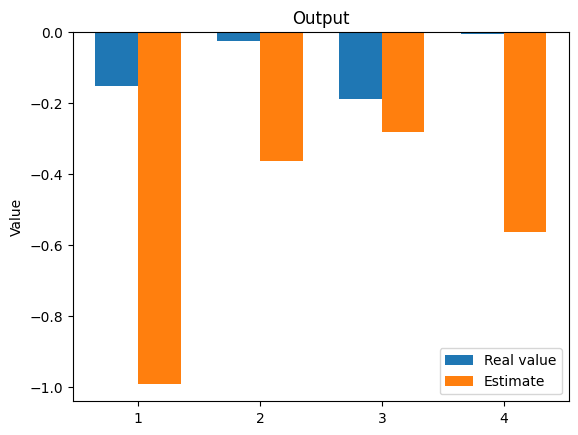

The function inverse took 1482.6472022533417 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/2


Running chain, α = 0.14:  35%|███▌      | 2821/8000 [02:27<04:31, 19.08it/s]


KeyboardInterrupt: 

In [23]:
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=0.05, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive, algo="AM")
estimate_LF=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=0.05, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive, algo="AM")
estimate_HF=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=0.05, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,algo="AM")

real values are [1. 2. 3. 4.]
Sampling chain 1/8


Running chain, α = 0.76: 100%|██████████| 4000/4000 [05:41<00:00, 11.71it/s]


Sampling chain 2/8


Running chain, α = 0.76: 100%|██████████| 4000/4000 [05:45<00:00, 11.59it/s]


Sampling chain 3/8


...

Sampling chain 7/8


Running chain, α = 0.79: 100%|██████████| 4000/4000 [05:44<00:00, 11.62it/s]


Sampling chain 8/8


Running chain, α = 0.80: 100%|██████████| 4000/4000 [05:42<00:00, 11.68it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.504 2.394 2.441 2.528]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.504  0.658   1.391    3.600      0.145    0.113      22.0      31.0   
x1  2.394  0.759   1.109    3.801      0.173    0.124      19.0      27.0   
x2  2.441  0.663   1.280    3.619      0.147    0.107      21.0      79.0   
x3  2.528  0.694   1.084    3.676      0.103    0.074      45.0     105.0   

    r_hat  
x0   1.28  
x1   1.35  
x2   1.31  
x3   1.16  
Autocorrelation...
the difference between estimated values [1.504 0.394 0.559 1.472]
 the difference between outputs of two models are [0.98382145 0.10013554 0.19076151 0.54535177]


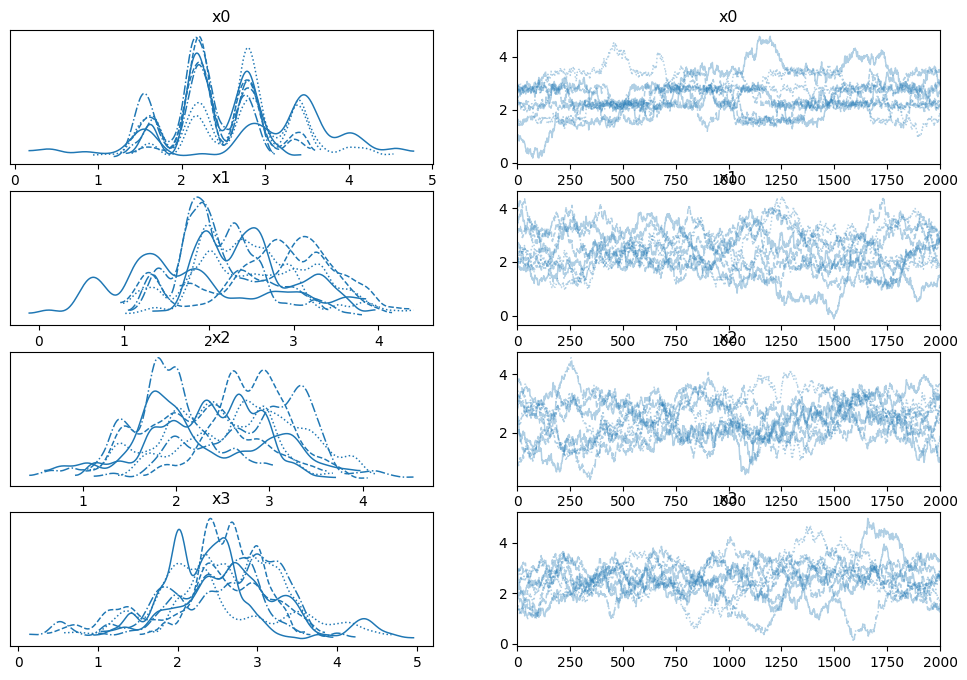

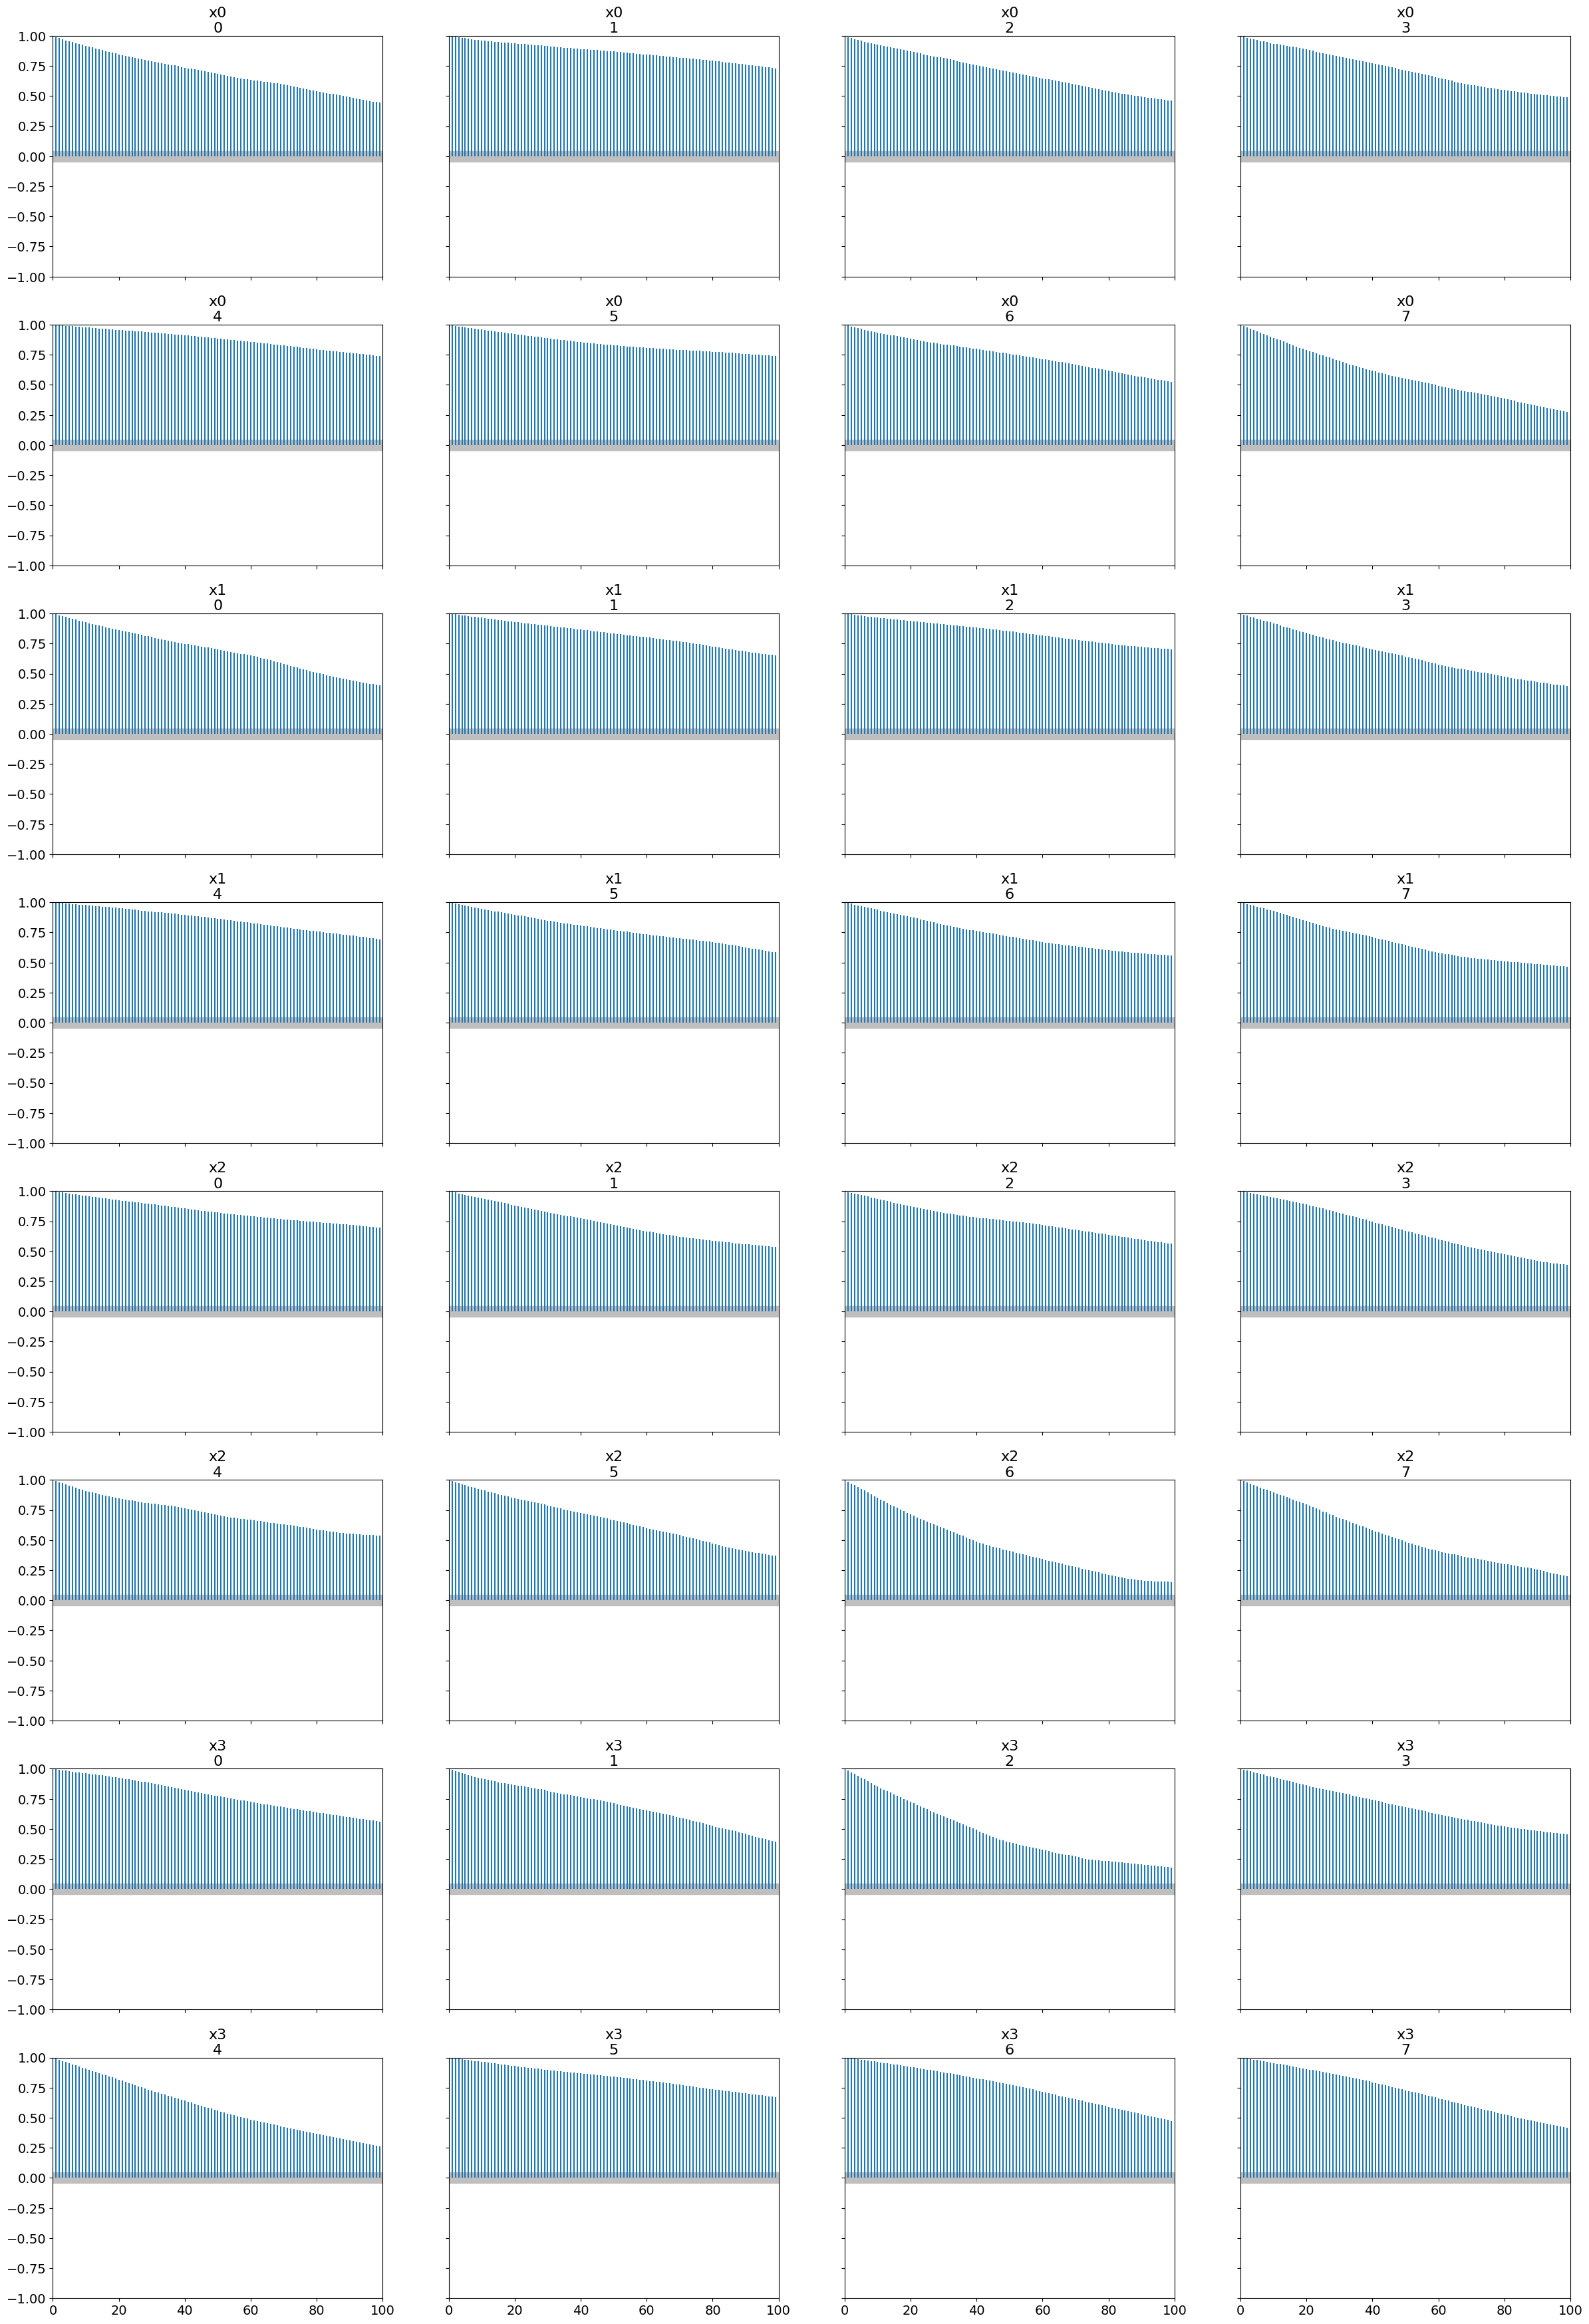

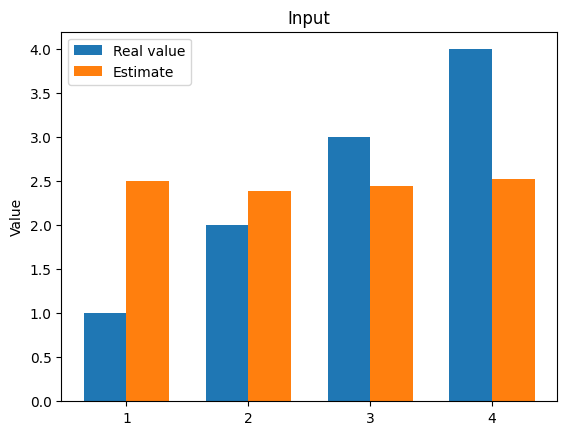

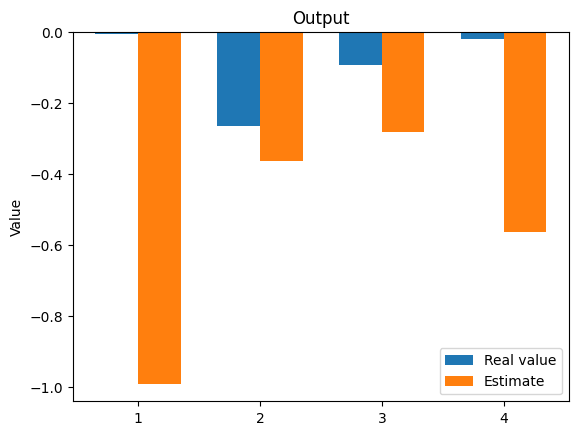

The function inverse took 2790.88246011734 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/8


Running chain, α = 0.68: 100%|██████████| 4000/4000 [03:00<00:00, 22.11it/s]


Sampling chain 2/8


Running chain, α = 0.64: 100%|██████████| 4000/4000 [03:01<00:00, 22.07it/s]


Sampling chain 3/8


...

Sampling chain 7/8


Running chain, α = 0.61: 100%|██████████| 4000/4000 [03:02<00:00, 21.98it/s]


Sampling chain 8/8


Running chain, α = 0.71: 100%|██████████| 4000/4000 [03:02<00:00, 21.90it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.036 2.637 2.467 2.489]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.036  0.521   0.936    2.553      0.168    0.122      20.0      19.0   
x1  2.637  0.745   1.280    3.872      0.193    0.140      16.0      88.0   
x2  2.467  0.626   1.620    3.897      0.177    0.132      15.0      37.0   
x3  2.489  0.637   1.667    3.861      0.179    0.130      15.0      17.0   

    r_hat  
x0   1.32  
x1   1.43  
x2   1.50  
x3   1.50  
Autocorrelation...
the difference between estimated values [1.036 0.637 0.533 1.511]
 the difference between outputs of two models are [0.26002795 1.1448256  0.84835994 1.022727  ]


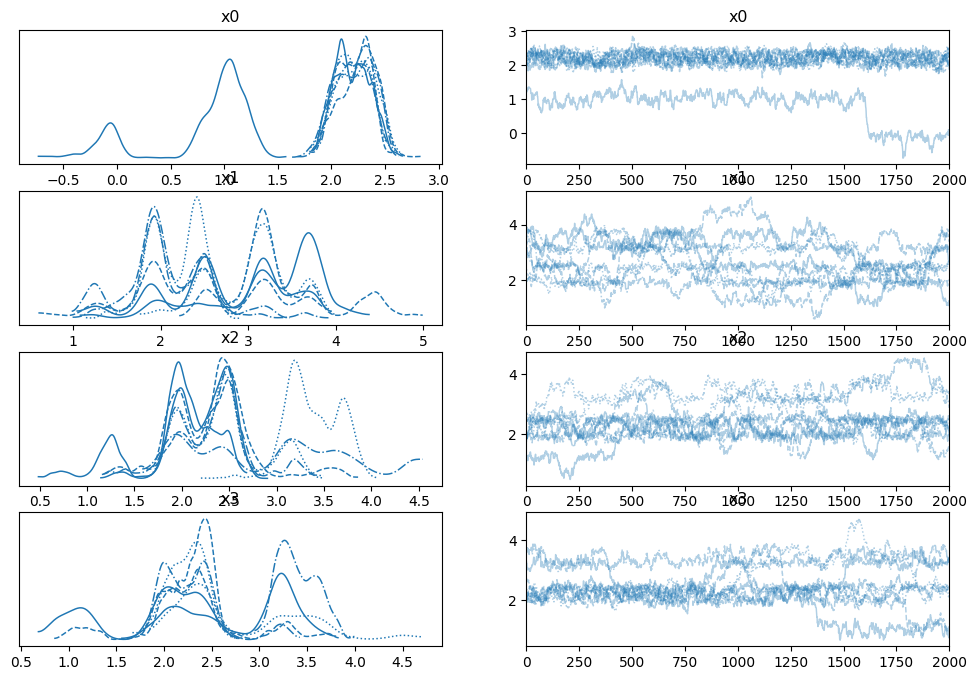

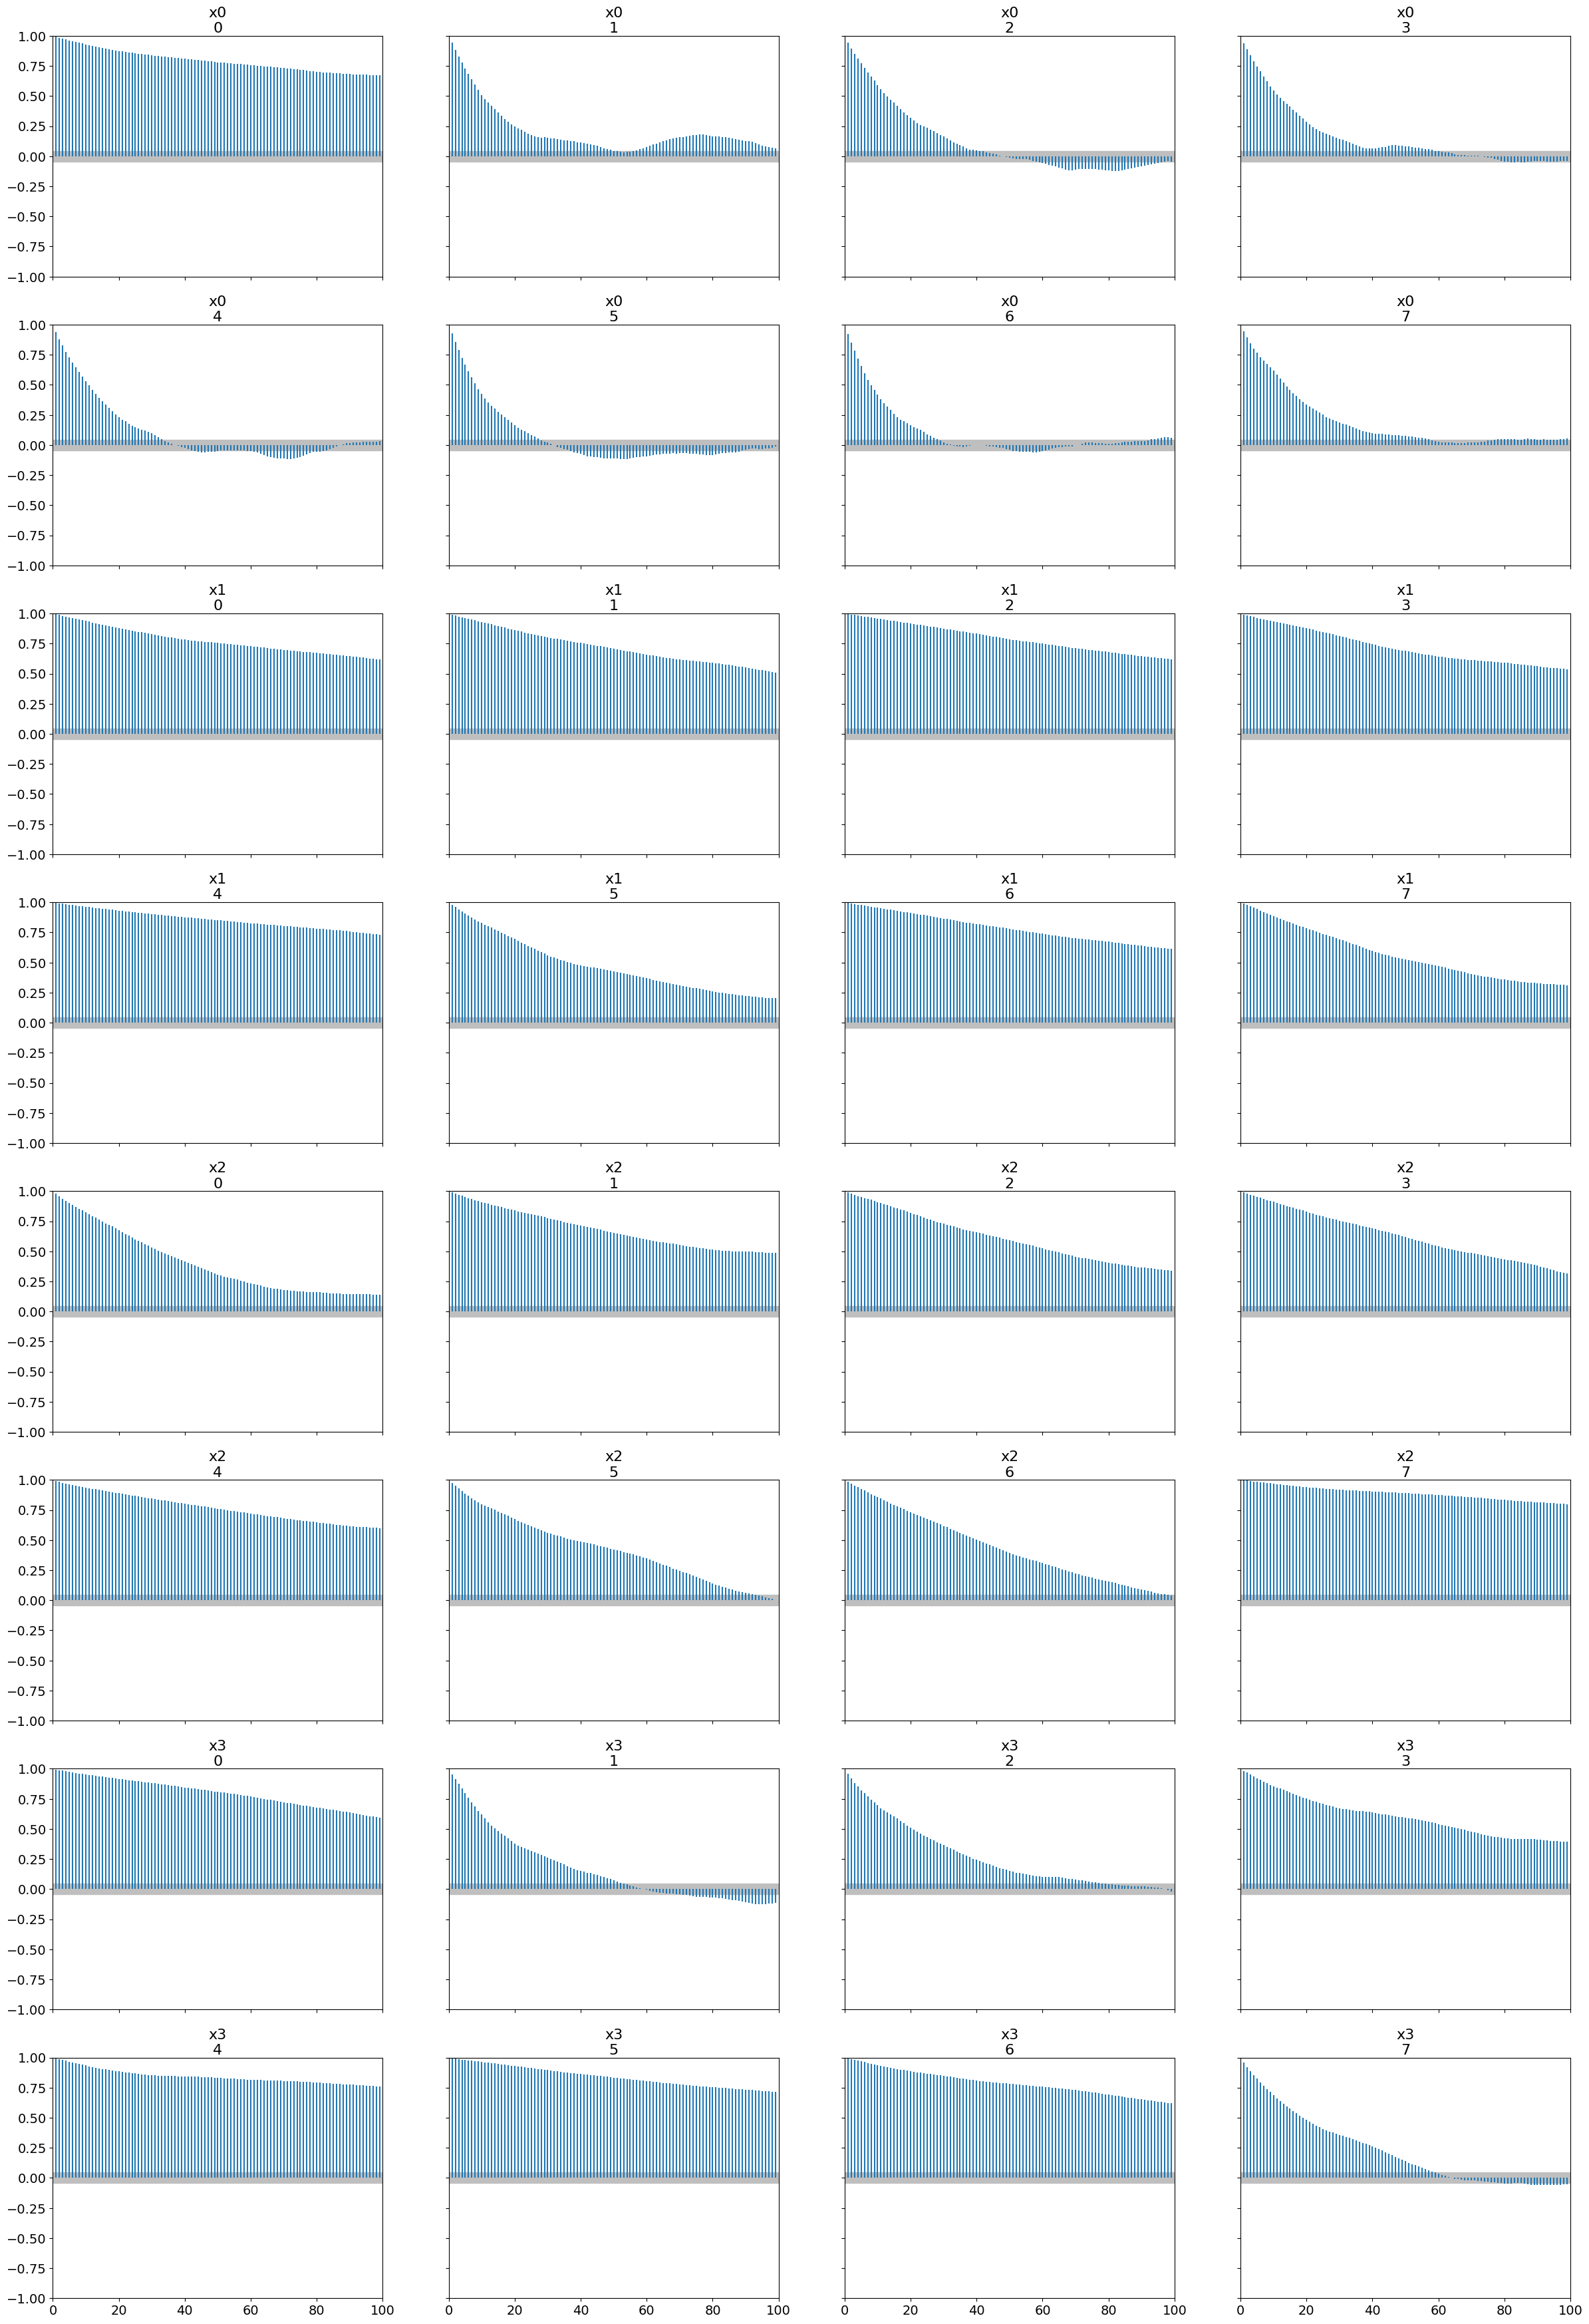

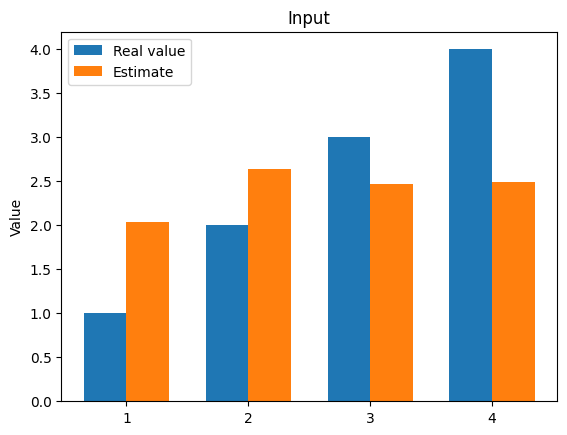

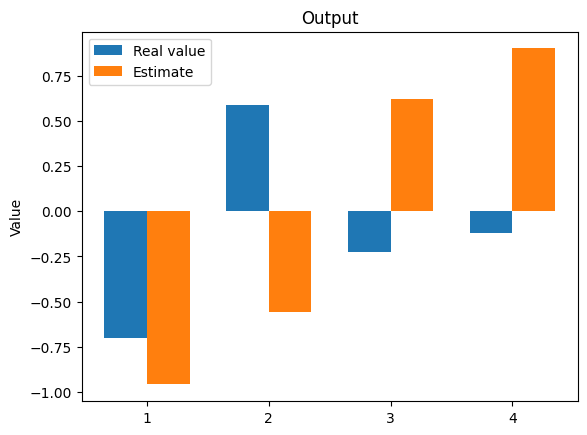

The function inverse took 1469.2587203979492 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/8


Running chain, α = 0.79: 100%|██████████| 4000/4000 [03:02<00:00, 21.93it/s]


Sampling chain 2/8


Running chain, α = 0.88: 100%|██████████| 4000/4000 [03:02<00:00, 21.97it/s]


Sampling chain 3/8


...

Sampling chain 7/8


Running chain, α = 0.83: 100%|██████████| 4000/4000 [03:02<00:00, 21.93it/s]


Sampling chain 8/8


Running chain, α = 0.81: 100%|██████████| 4000/4000 [03:02<00:00, 21.90it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.57  2.544 2.253 2.629]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.570  0.610   1.327    3.782      0.115    0.082      29.0      93.0   
x1  2.544  0.570   1.529    3.654      0.108    0.077      28.0     180.0   
x2  2.253  0.765   0.806    3.539      0.137    0.098      33.0     207.0   
x3  2.629  0.699   1.302    3.961      0.174    0.125      17.0      24.0   

    r_hat  
x0   1.19  
x1   1.21  
x2   1.19  
x3   1.43  
Autocorrelation...
the difference between estimated values [1.57  0.544 0.747 1.371]
 the difference between outputs of two models are [0.34977537 0.87378925 0.21501541 0.00615335]


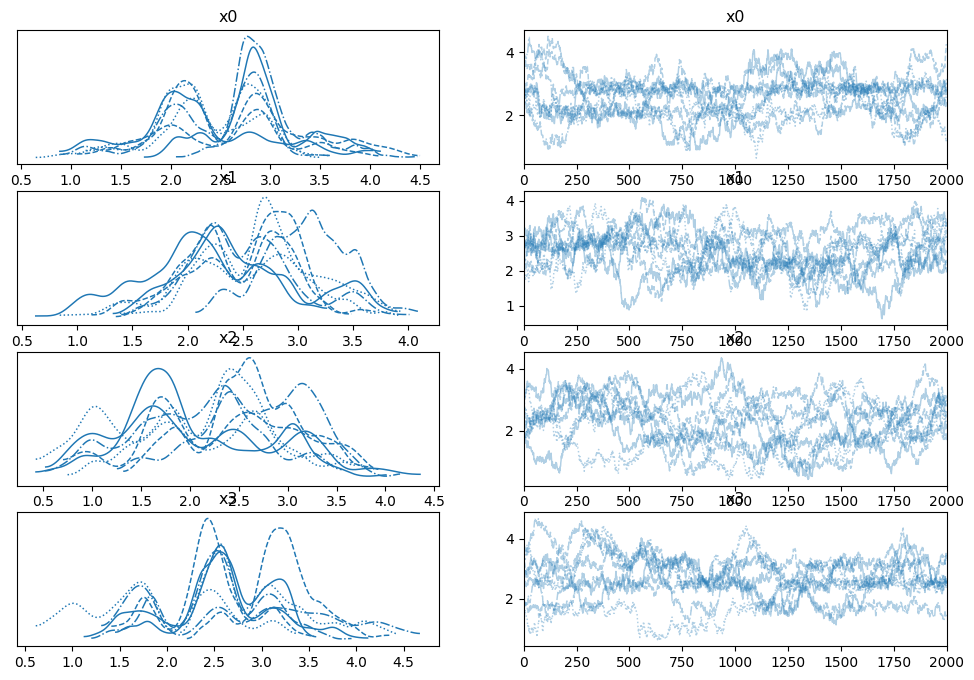

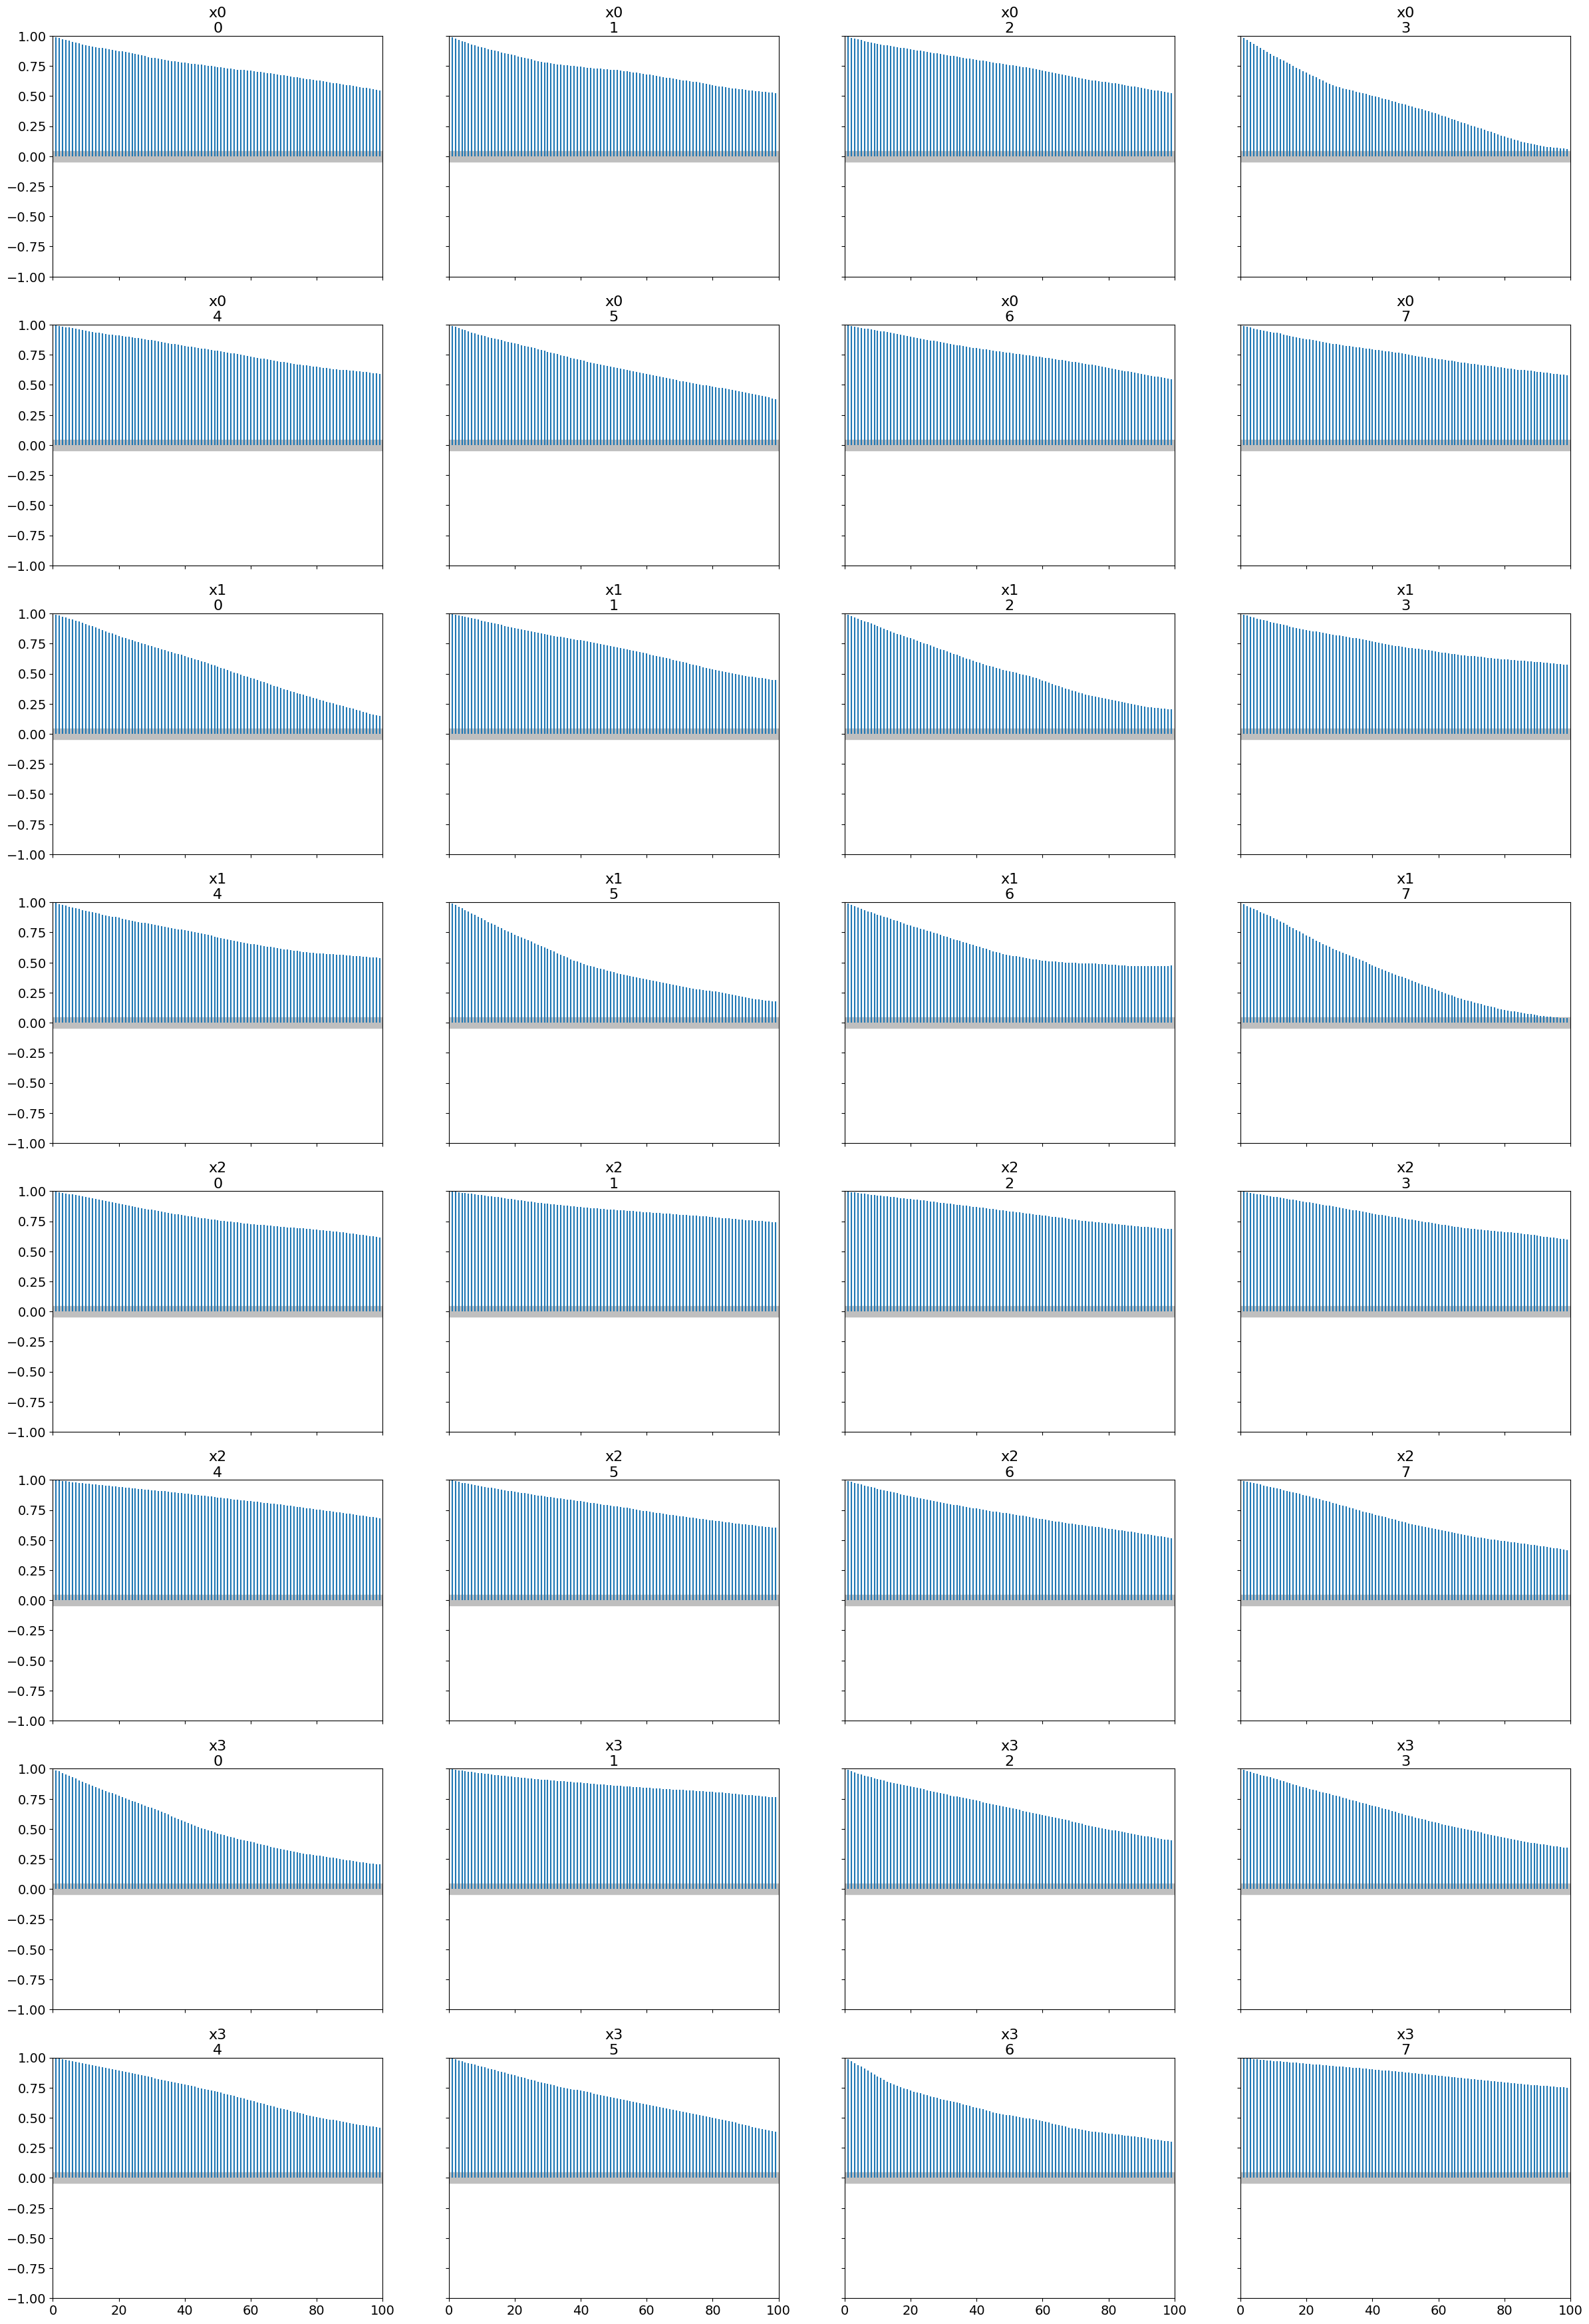

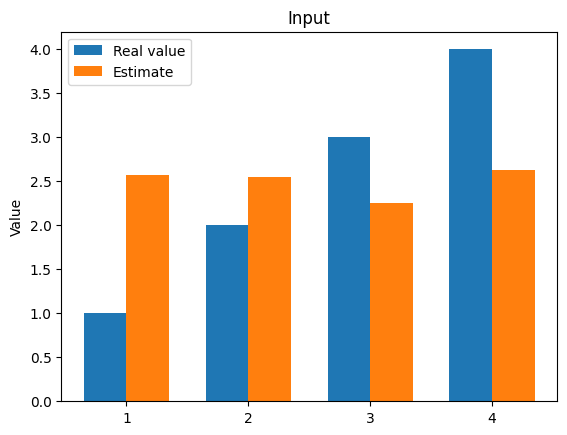

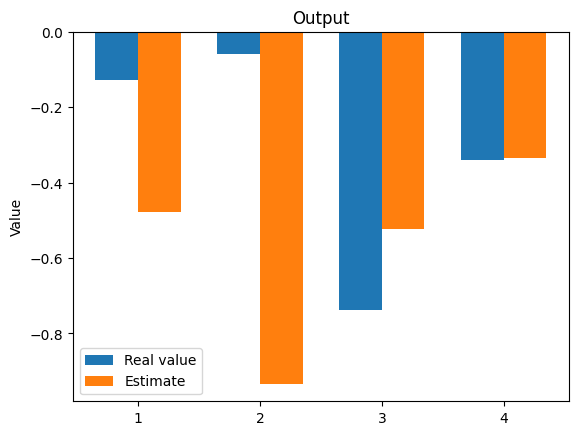

The function inverse took 1474.225112915039 seconds.


In [11]:
estimate_MF2=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)
estimate_LF2=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)
estimate_HF2=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

provare caso base con cov !=0 cosi da vedere se esiste miglioramento. Usa metodo per derivarla

In [9]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([0.5,1.5,2.5,3.5])
mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.5  # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.6
rwmh_cov = np.eye(len(real_x))*3 # !
rmwh_scaling = 0.1
rwmh_adaptive = False
#iterations =20000
#burnin = 5000
iterations=3000#8000
burnin=1000#4000
n_chains=2

# MF

real values are [0.5 1.5 2.5 3.5]
Sampling chain 1/2


Running chain, α = 0.62: 100%|██████████| 3000/3000 [09:24<00:00,  5.31it/s]  


Sampling chain 2/2


Running chain, α = 0.62: 100%|██████████| 3000/3000 [07:44<00:00,  6.46it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.471 2.58  2.062 2.569]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.471  1.306  -0.937    4.054      0.631    0.512       5.0      24.0   
x1  2.580  1.268   0.250    4.766      0.517    0.385       6.0      52.0   
x2  2.062  2.081  -1.678    5.414      1.201    0.949       3.0      41.0   
x3  2.569  1.287   0.201    4.792      0.327    0.235      16.0      63.0   

    r_hat  
x0   1.40  
x1   1.25  
x2   1.71  
x3   1.12  
Autocorrelation...
the difference between estimated values [0.971 1.08  0.438 0.931]
 the difference between outputs of two models are [0.41492748 0.88390216 0.66458201 0.54895845]


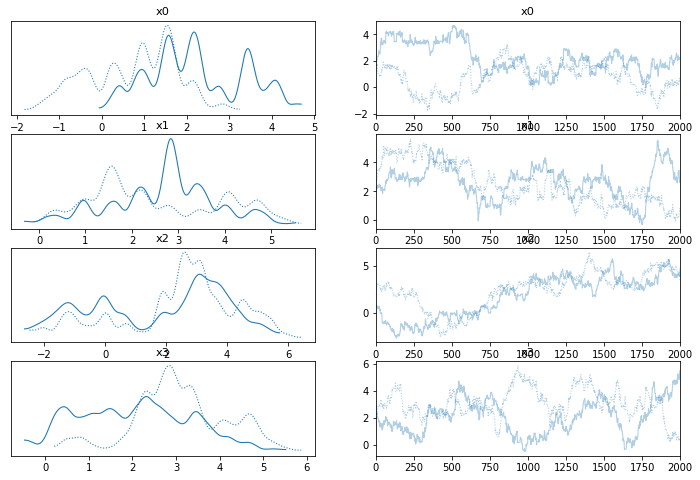

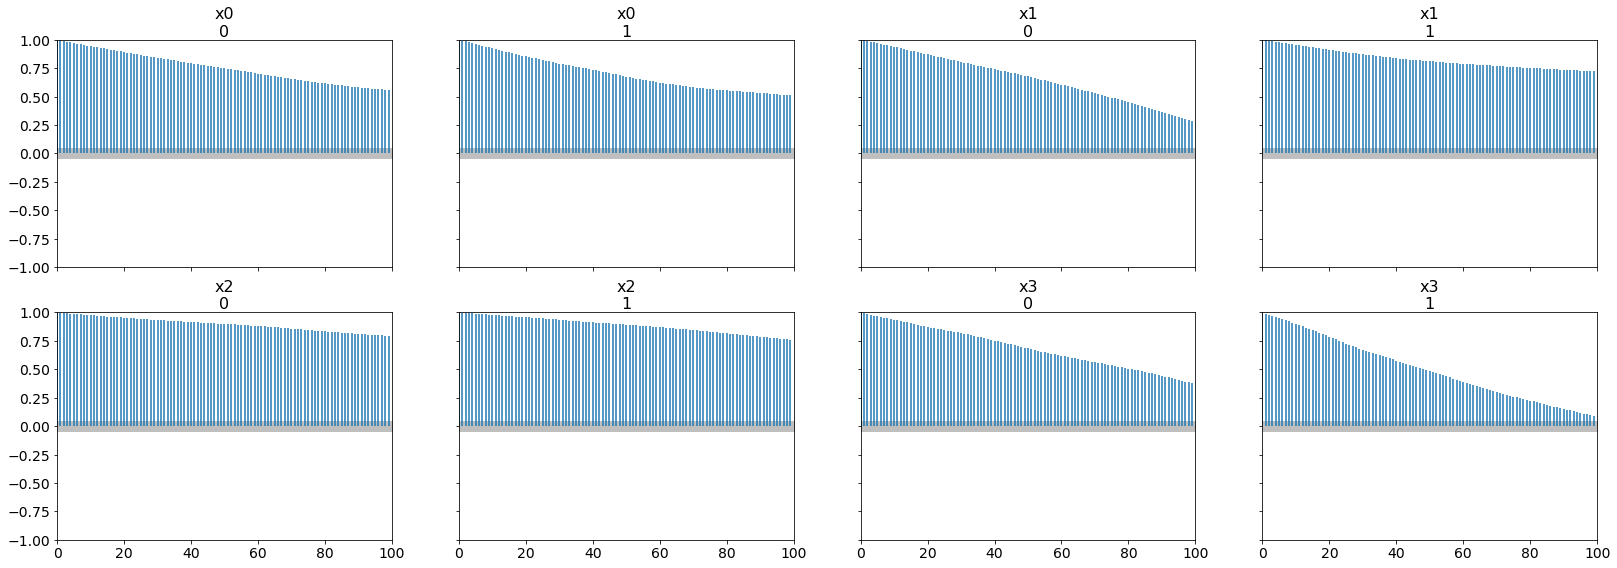

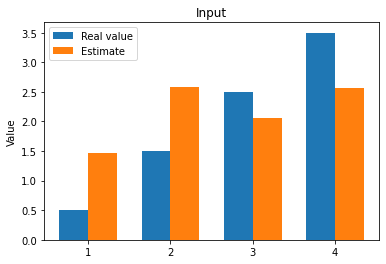

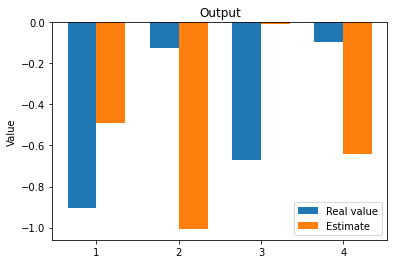

The function inverse took 1090.0222253799438 seconds.


In [19]:

estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

real values are [0.5 1.5 2.5 3.5]
Sampling chain 1/2


Running chain, α = 0.17: 100%|██████████| 3000/3000 [08:21<00:00,  5.98it/s]


Sampling chain 2/2


Running chain, α = 0.12: 100%|██████████| 3000/3000 [09:08<00:00,  5.47it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.657 1.788 1.972 2.531]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.657  1.626  -0.163    5.637      0.145    0.103     125.0     312.0   
x1  1.788  1.366  -0.590    4.152      0.100    0.072     191.0     284.0   
x2  1.972  1.410  -0.532    4.641      0.101    0.071     198.0     306.0   
x3  2.531  1.646  -0.315    5.714      0.200    0.142      68.0     232.0   

    r_hat  
x0   1.00  
x1   1.02  
x2   1.01  
x3   1.04  
Autocorrelation...
the difference between estimated values [2.157 0.288 0.528 0.969]
 the difference between outputs of two models are [0.06437531 0.8314558  0.22248833 0.62147695]


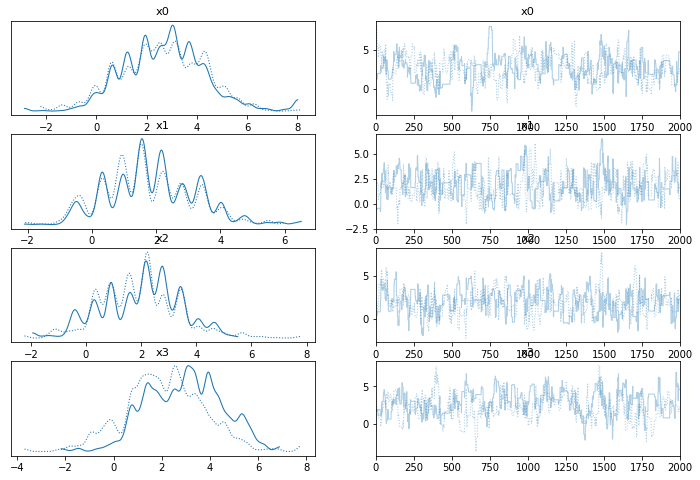

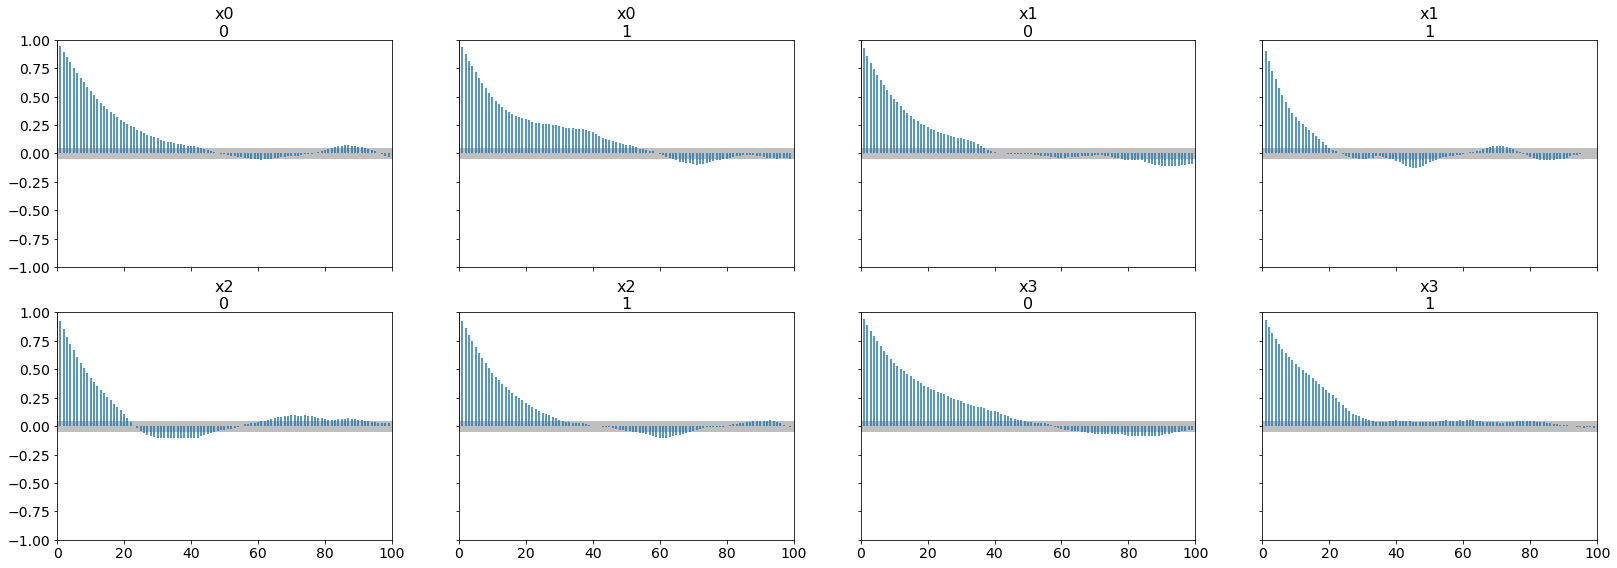

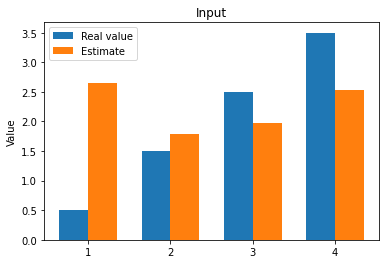

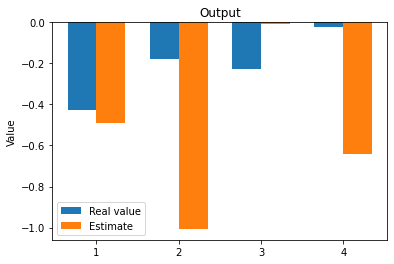

The function inverse took 1106.027232170105 seconds.


In [20]:
rwmh_adaptive = True
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

real values are [0.5 1.5 2.5 3.5]
Sampling chain 1/2


Running chain, α = 0.27: 100%|██████████| 3000/3000 [19:11<00:00,  2.61it/s]


Sampling chain 2/2


Running chain, α = 0.19: 100%|██████████| 3000/3000 [16:16<00:00,  3.07it/s] 
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


estimated values are [2.22  2.699 2.49  2.407]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.220  1.559  -0.639    4.959      0.099    0.070     251.0     464.0   
x1  2.699  1.551  -0.735    5.298      0.097    0.068     258.0     367.0   
x2  2.490  1.554  -0.674    5.179      0.094    0.067     274.0     347.0   
x3  2.407  1.534  -0.591    5.195      0.106    0.075     213.0     257.0   

    r_hat  
x0   1.03  
x1   1.00  
x2   1.01  
x3   1.01  


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


Autocorrelation...
the difference between estimated values [1.72  1.199 0.01  1.093]
 the difference between outputs of two models are [0.45258778 0.40696937 0.00324985 0.45447341]


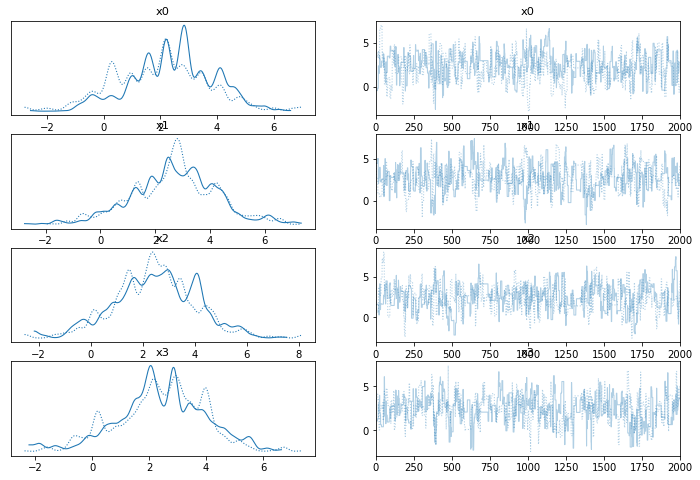

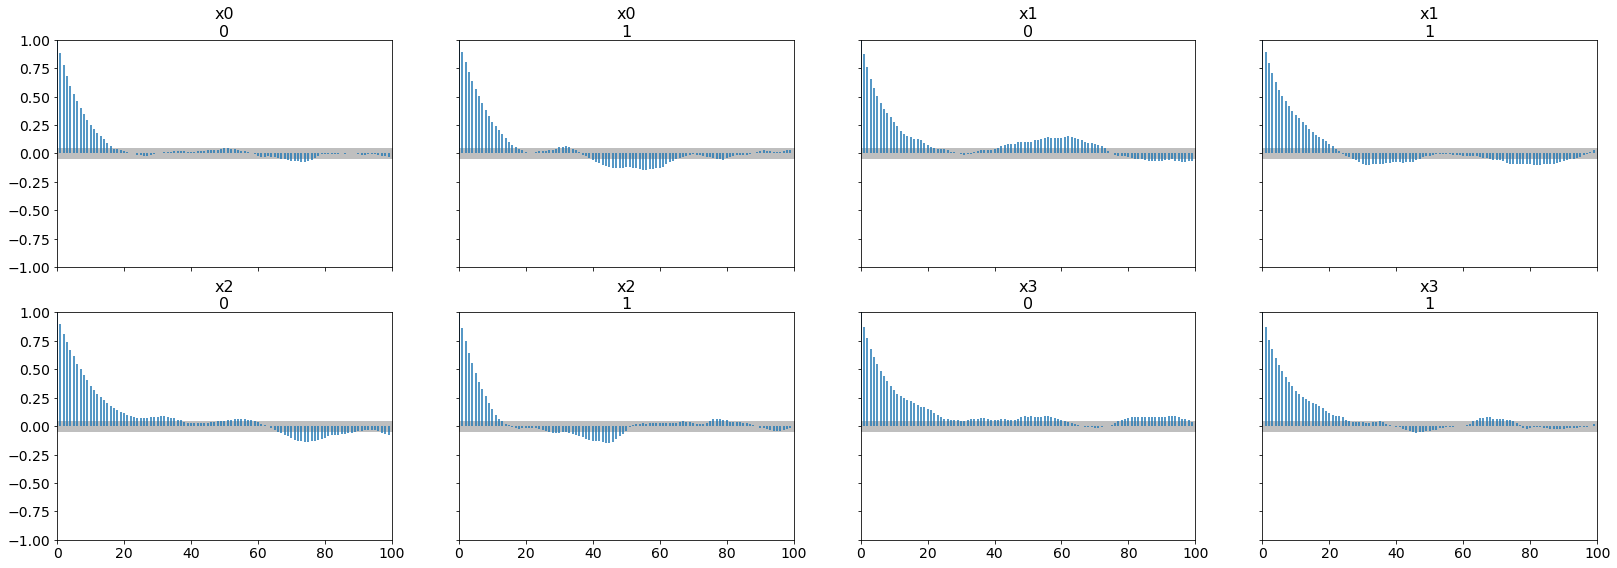

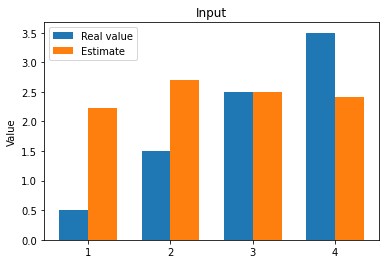

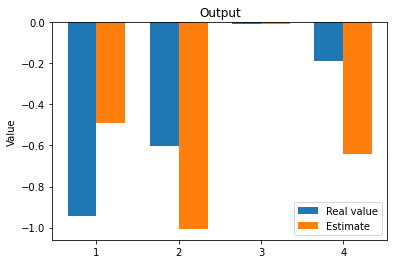

The function inverse took 2262.3574619293213 seconds.


In [11]:
rwmh_adaptive = True
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,algo="AM")

### Low Fidelity

real values are [0.5 1.5 2.5 3.5]
Sampling chain 1/2


Running chain, α = 0.68: 100%|██████████| 3000/3000 [04:09<00:00, 12.03it/s]


Sampling chain 2/2


Running chain, α = 0.68: 100%|██████████| 3000/3000 [03:53<00:00, 12.87it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.356 3.823 2.886 1.603]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.356  1.016  -0.340    3.604      0.347    0.300      10.0      31.0   
x1  3.823  1.249   1.866    5.776      0.829    0.684       3.0      25.0   
x2  2.886  1.079   1.183    5.248      0.273    0.212      17.0      31.0   
x3  1.603  2.129  -2.726    5.181      1.159    0.903       3.0      14.0   

    r_hat  
x0   1.24  
x1   2.06  
x2   1.11  
x3   1.61  
Autocorrelation...
the difference between estimated values [0.856 2.323 0.386 1.897]
 the difference between outputs of two models are [0.12219098 0.71676946 1.0030972  1.951877  ]


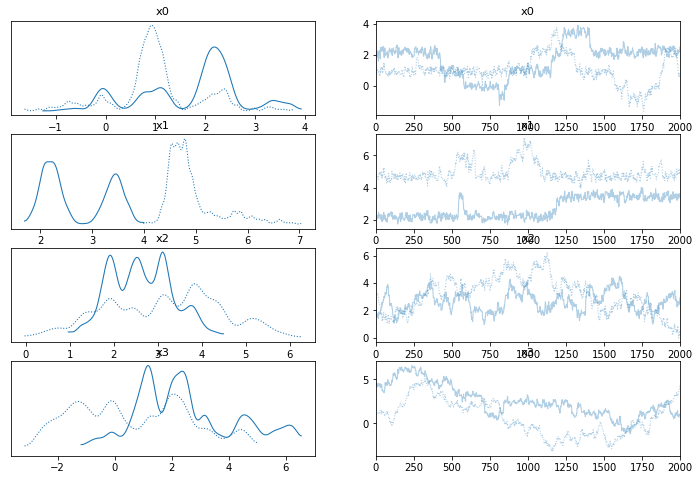

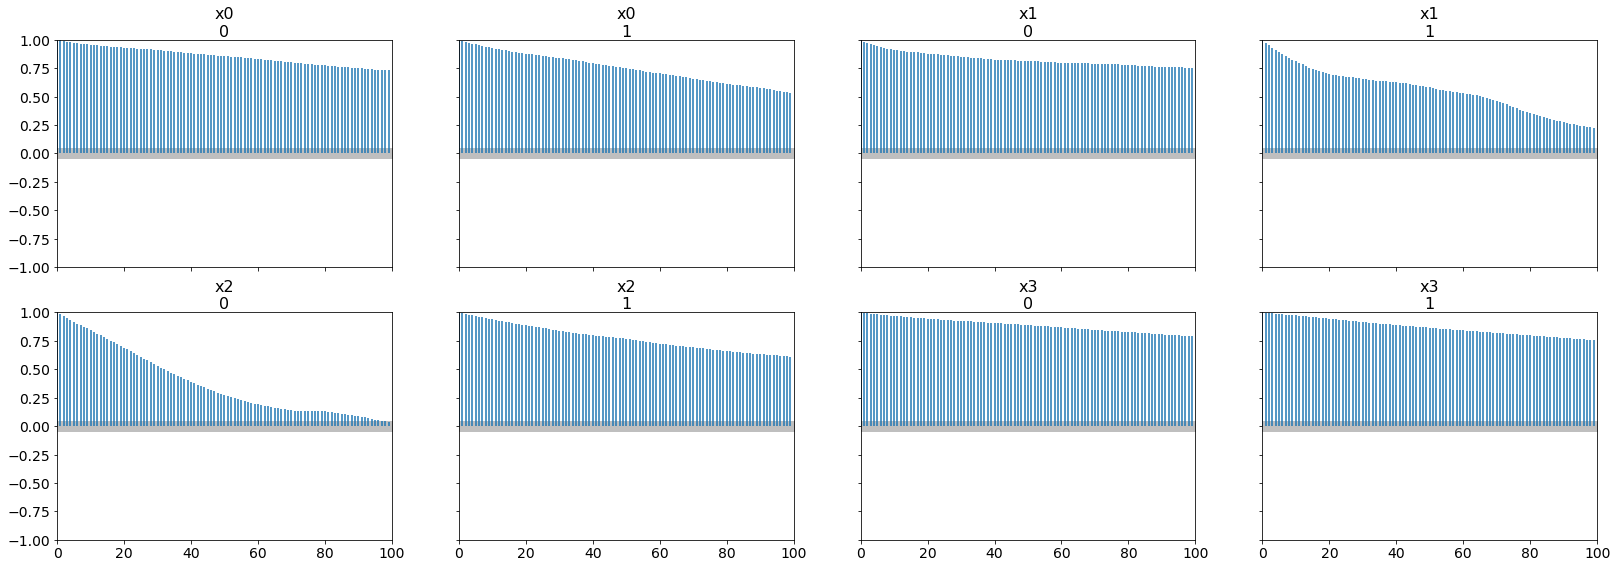

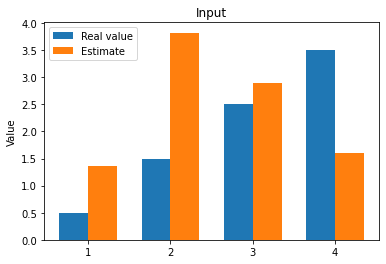

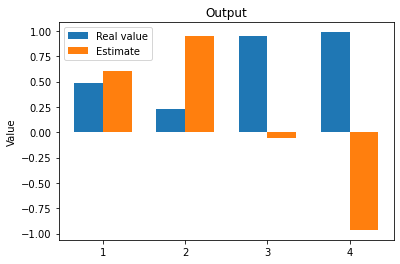

The function inverse took 507.73793148994446 seconds.


In [21]:
rwmh_adaptive = False
estimate_LF=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

## High fidelity


In [22]:
estimate_HF=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

real values are [0.5 1.5 2.5 3.5]
